## Setup for EDA and time series 

In [1805]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [1806]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report

from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing


from statsmodels.tsa.statespace.sarimax import SARIMAX
#New Libraries
#from statsmodels.tsa.statespace.sarimax import SARIMAX
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100
import matplotlib.dates as mdates  


In [1807]:
#from statsmodels.tsa.stattools import adfuller
#!pip install pmdarima --quiet
#import pmdarima as pm


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 
- df_dt is final dataframe for XG Boost regressor (only contain the 'datatime' and  'target' features)

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [1808]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [1809]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [1810]:
#res_df.dtypes

In [1811]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [1812]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [1813]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [1814]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [1815]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [1816]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [1817]:
data_df_gwh = data_df_mwh.copy()

In [1818]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [1819]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [1820]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [1821]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [1822]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [1823]:

data_df= data_df_gwh.copy()

In [1824]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [1825]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [1826]:
##data_df.columns

In [1827]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [1828]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
#main_0  = 'Total_energy_generation_gwh' # This is only for energy
main_0  = 'Solar_gwh' # for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'energy generation')# for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
#target = 'Total_energy_generation_gwh'
target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', ' energy generation (GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Solar energy generation
Solar energy generation (GWh)


### Here we set the function for line plot  

In [1829]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'energy in (GWh)'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', 'energy in (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'energy in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.sum}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', ' energy in (GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



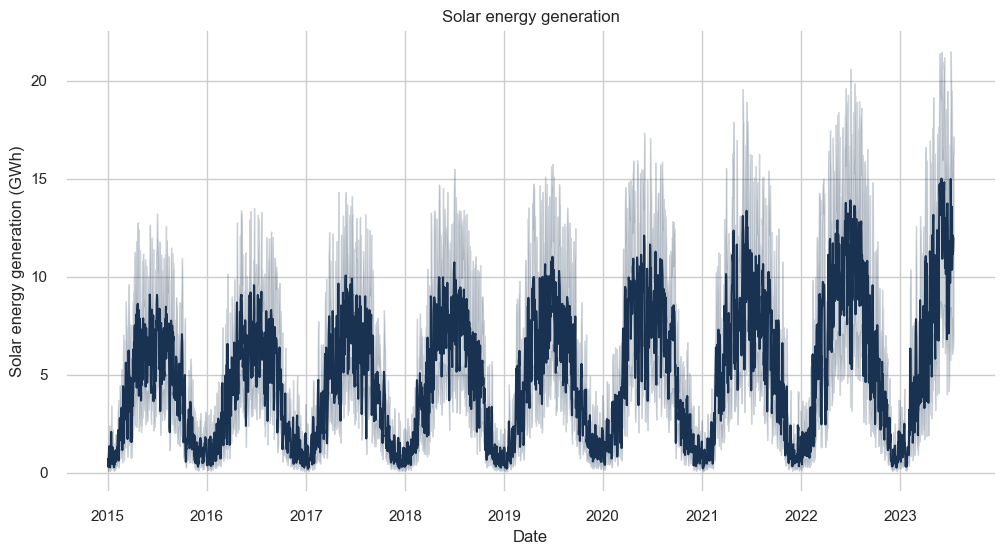

In [1830]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [1831]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [1832]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [1833]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

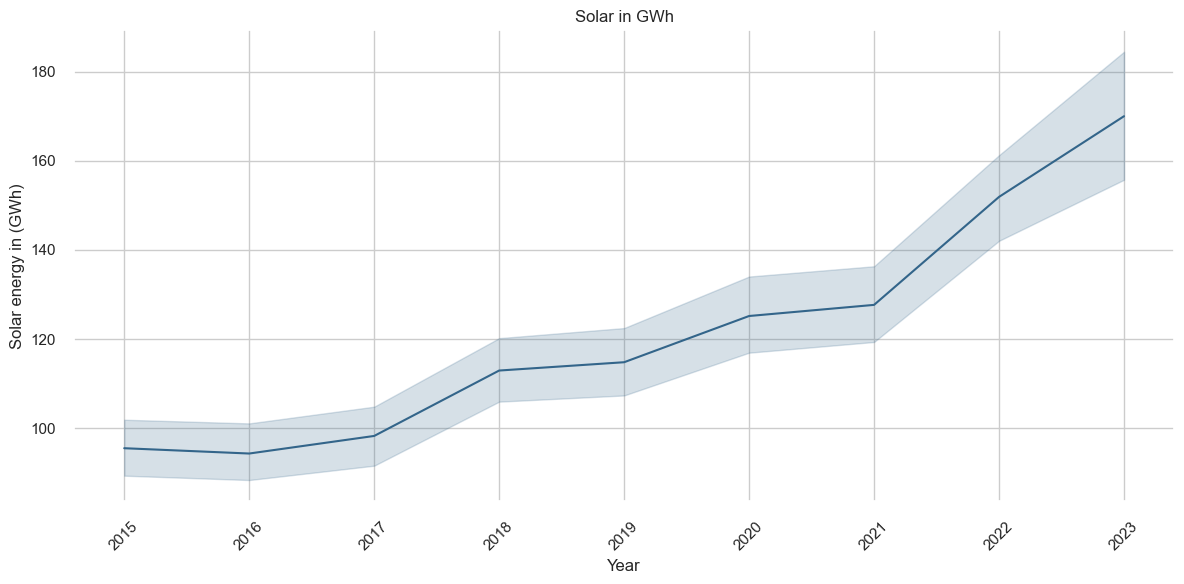

In [1834]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [1835]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [1836]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Solar_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,0.00000
2015-01-01,2015,1,1,1,1,0.00000
2015-01-01,2015,1,1,1,2,0.00000
2015-01-01,2015,1,1,1,3,0.00000
2015-01-01,2015,1,1,1,4,0.00000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,10.08425
2023-07-17,2023,7,17,198,19,4.72400
2023-07-17,2023,7,17,198,20,1.51125


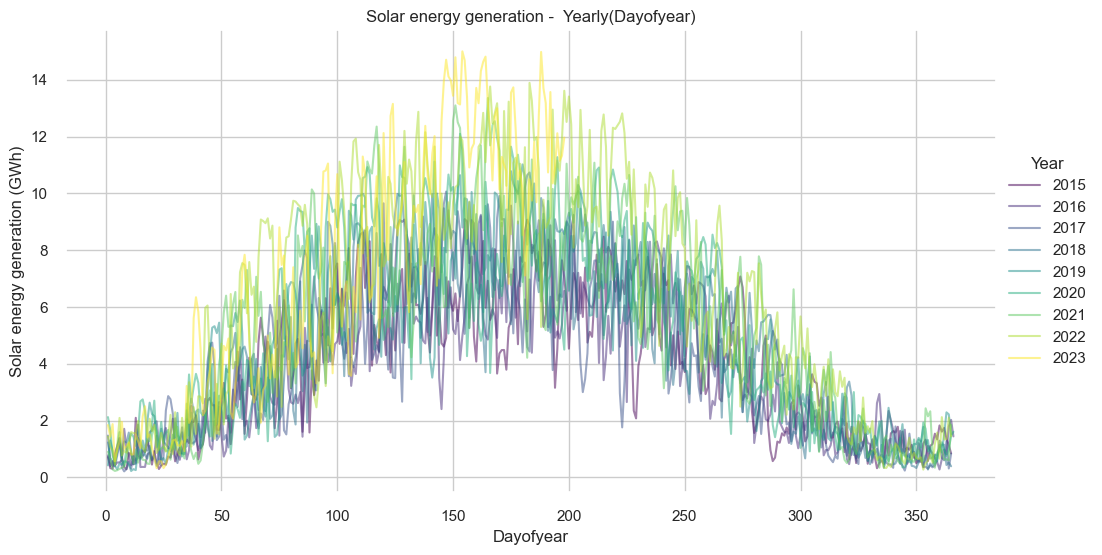

In [1837]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [1838]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [1839]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

In [1840]:
#data_df.columns

In [1841]:
df_c = data_df.copy()

In [1842]:
#df_c.columns

In [1843]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result

In [1844]:
df_dt = combine_date_and_time(df_c, date_column='Date', time_column='Hour', target_column=target)

In [1845]:
df_dt.columns

Index(['Datetime', 'Solar_gwh'], dtype='object')

In [1846]:
df_dt.head()

,Datetime,Solar_gwh
0,2015-01-01 00:00:00,0.0
1,2015-01-01 01:00:00,0.0
2,2015-01-01 02:00:00,0.0
3,2015-01-01 03:00:00,0.0
4,2015-01-01 04:00:00,0.0


In [1847]:

#df_c = data_df.copy()
#df_c = data_df[['Date',  target]]
#df_dt = df_dt.set_index('Datetime')
#df_dt.plot(style = '-', figsize = (15,5), color='#1f76b4')

In [1848]:
#df_dt.loc[(df_dt.index > '2023-01-01') & (df_dt.index < '2023-12-01') ].plot(figsize=(15,5), ylabel=ylable_target, title= 'Data of last year', label = '2023 data')
#ax.legend(['2023 data'])
#plt.show()

In [1849]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    #df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
   # df['Week'] = df.index.week
    df['Day'] = df.index.day
    #df['Dayofyear'] = df.index.dayofyear
    return df


In [1850]:
#df_dt = create_features(df_dt)
#df_dt.head()

In [1851]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Hour', y =target)
#ax.set_title( title_main + '' + ' ' 'by hour')
#ax.set_ylabel(ylable_target)

In [1852]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Month', y =target)
#ax.set_title(title_main + '' + ' ' 'by month')
#ax.set_ylabel(ylable_target)

In [1853]:
#fig, ax = plt.subplots(figsize=(15,5))
#sns.boxplot (data=df_dt, x= 'Day', y =target)
#ax.set_title(title_main + '' + ' ' 'by day')
#ax.set_ylabel(ylable_target)

            Year  Solar_gwh
Date                       
2015-01-01  2015   17.08025
2015-01-02  2015    7.75900
2015-01-03  2015    7.23475
2015-01-04  2015   19.98250
2015-01-05  2015   26.52225
2015-01-06  2015   32.88725
2015-01-07  2015   17.11475
2015-01-08  2015    8.59825
2015-01-09  2015    6.82375
2015-01-10  2015   20.47500
2015-01-11  2015   19.81125
2015-01-12  2015   11.02500


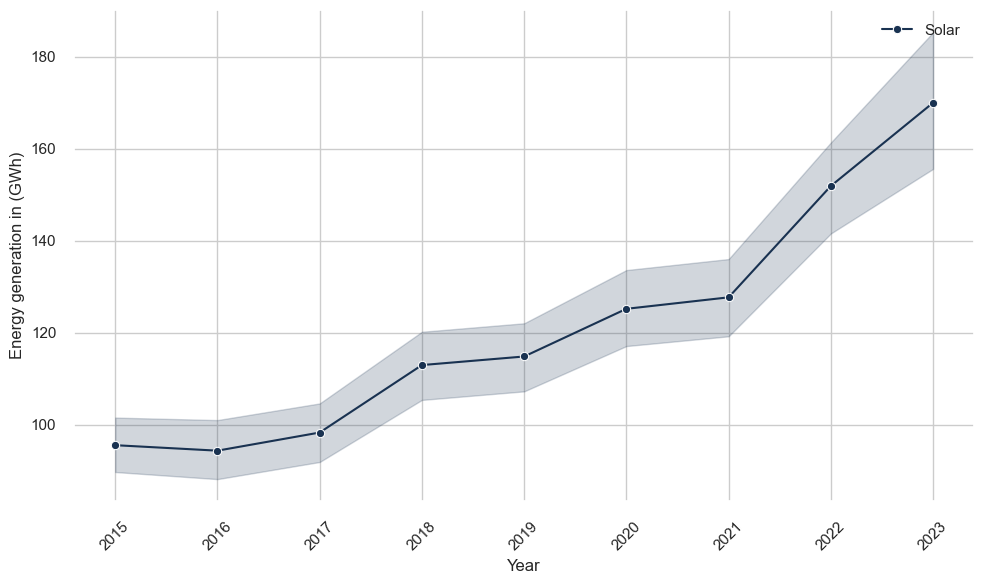

In [1854]:
def average_lineplot(df, y_values, x='Date', time='Year'):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)
        #print(grouped_df,  grouped_df.shape, df, df.shape)
        print(grouped_df[0:12])

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

def simple_lineplot(df, y_values, x='Date', time=' '):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df #\
        #    .groupby([x, time], as_index=False) \
        #    .agg({y: np.sum}) \
        #    .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

average_lineplot(df=data_df, y_values=['Solar_gwh'], x="Date", time='Year')   
#
#
#average_lineplot(df=data_df, y_values=['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month') 
#average_lineplot(df=data_df, y_values=['Total_energy_generation_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')
#average_lineplot(df=data_df, y_values=['Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')


#simple_lineplot(df=data_df, y_values=['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month') 
#
#
#simple_lineplot(df=data_df, y_values=['Mean_air_temperature_de_c',
#        'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm',
#        'Spot_market_price_eur_per_gwh',
#        'Co2_emission_allowances_auction_eur_per_tco2'], x="Date", time='Month')   

In [1855]:
data_df_twh = data_df.copy()
data_df_twh.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## From here we will use Twh unit

In [1856]:
# Here we convert  unit from gwh to mwh 
for col in ['Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh','Total_energy_generation_gwh', 'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh']:
       data_df_twh[col] =  data_df_twh[col]/1000.




# Here we rename columns from *_mwh to *_gwh
for col in data_df_twh.columns:
       data_df_twh.rename(columns={col:col.replace('gwh','Twh')},inplace=True)


In [1857]:
 data_df_twh.columns

Index(['Area', 'Mtu', 'Biomass_Twh', 'Fossil_brown_coal_Twh',
       'Fossil_coal_derived_gas_Twh', 'Fossil_gas_Twh', 'Fossil_hard_coal_Twh',
       'Fossil_oil_Twh', 'Fossil_oil_shale_Twh', 'Fossil_peat_Twh',
       'Geothermal_Twh', 'Hydro_pumped_storage_aggregated_Twh',
       'Hydro_pumped_storage_consumption_Twh',
       'Hydro_run_of_river_and_poundage_Twh', 'Hydro_water_reservoir_Twh',
       'Marine_Twh', 'Nuclear_Twh', 'Other_Twh', 'Other_renewable_Twh',
       'Solar_Twh', 'Waste_Twh', 'Wind_offshore_Twh', 'Wind_onshore_Twh',
       'Date', 'Hour', 'Total_energy_generation_Twh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_Twh', 'Total_other_renewable_Twh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [1858]:
data_df_twh.head()

,Area,Mtu,Biomass_Twh,Fossil_brown_coal_Twh,Fossil_coal_derived_gas_Twh,Fossil_gas_Twh,Fossil_hard_coal_Twh,Fossil_oil_Twh,Fossil_oil_shale_Twh,Fossil_peat_Twh,...,Date,Hour,Total_energy_generation_Twh,Solar/total_energy,Diff_total_energy_and_solar_Twh,Total_other_renewable_Twh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,0.003998,0.015687,0.0,0.001226,0.003220,0.000176,0.0,0.0,...,2015-01-01,0,0.051459,0.0,0.051459,0.009669,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,0.003956,0.015322,0.0,0.000871,0.002351,0.000174,0.0,0.0,...,2015-01-01,1,0.049988,0.0,0.049988,0.009862,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,0.003992,0.014818,0.0,0.000809,0.002227,0.000173,0.0,0.0,...,2015-01-01,2,0.049265,0.0,0.049265,0.010003,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,0.004010,0.014075,0.0,0.000821,0.002340,0.000173,0.0,0.0,...,2015-01-01,3,0.048538,0.0,0.048538,0.009973,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,0.004006,0.014115,0.0,0.000831,0.002462,0.000174,0.0,0.0,...,2015-01-01,4,0.048630,0.0,0.048630,0.010031,2015,1,1,1


#### Yearly average

In [1859]:

def plot_yearly_average(target, data_df, y_values, x='Date', time='Year', titlem ='Yearly average  solar energy production (DE)', ylabely = 'Solar energy generation (Gwh)'):
    # Convert the 'Date' column to datetime
    data_df['Date'] = pd.to_datetime(data_df['Date'])
    
    # Group data by the specified time interval (Year)
    grouped = data_df.groupby(pd.Grouper(key='Date', freq='Y'))[target].sum().reset_index()
    
    #print(grouped, grouped.shape)
    # Set plot style
    sns.set(style="whitegrid")
    
    # Create the plot
    #print(grouped[0:12], data_df[x], data_df[y_values])

    fig, ax = plt.subplots(figsize=(12,4))
    #plt.figure(figsize=(10, 6))
    #ax = sns.lineplot(data=grouped, x=x, y=y_values, color='#1f76b4', linewidth=4, marker='o', markersize=8, markeredgewidth=8)
    ax = sns.lineplot(data=grouped, x=x, y=y_values, color='#1f76b4', linewidth=3, marker='o', markersize=8)
    plt.xlabel('Date')
    plt.ylabel(ylabely)#('Solar energy generation (Gwh)')
    plt.title(titlem)#('Yearly average  solar energy production (DE)')    
    # Set x-axis date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
    # Set x-axis limits based on data range
    start_date = pd.Timestamp('2015-12-31')
    end_date = pd.Timestamp('2022-12-31')

    plt.xlim(start_date, end_date)
    #plt.ylim(460000,570000)
    #plt.ylim(460,570)
    # Show the plot
    plt.tight_layout()
    #sns.despine()
    # Remove top, right, and bottom spines (frame) of the plot
    sns.despine(top=True, right=True, left=True, bottom=True)
    plt.show()

    ## Energy development over year (time)
    #fig, ax = plt.subplots()
    #sns.lineplot(data=grouped, x=x, y=y_values, marker='o', color='#1f76b4')
    #ax.set(title='Yearly average  solar energy production (DE', ylabel= 'Solar energy generation (Gwh)', xlabel = 'Year');


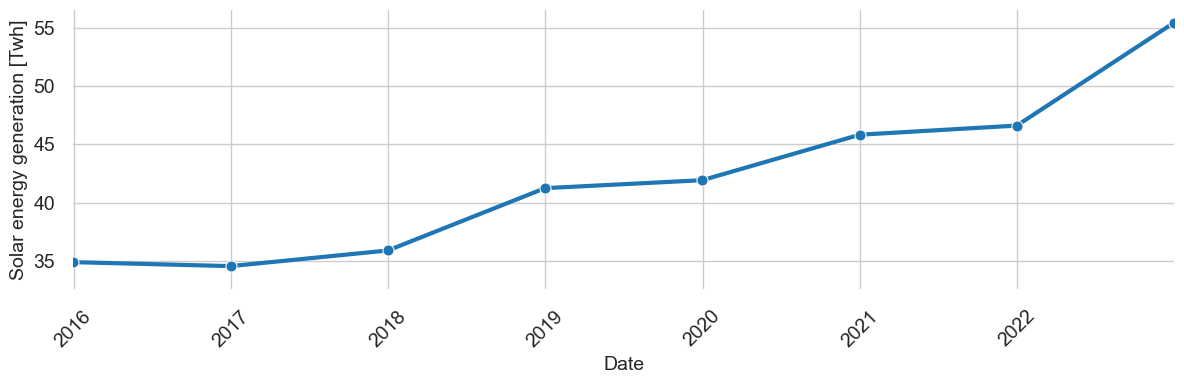

In [1860]:
def plot_yearly_average1(target, data_df, y_values, x='Date', time='Year', titlem ='Yearly average solar energy production (DE)', ylabely = 'Solar energy generation (Gwh)'):
    # Convert the 'Date' column to datetime
    data_df['Date'] = pd.to_datetime(data_df['Date'])
    
    # Group data by the specified time interval (Year)
    grouped = data_df.groupby(pd.Grouper(key='Date', freq='Y'))[target].sum().reset_index()
    
    # Set plot style
    sns.set(style="whitegrid")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 4))
    ax = sns.lineplot(data=grouped, x=x, y=y_values, color='#1f76b4', linewidth=3, marker='o', markersize=8)
    
    plt.xlabel('Date', fontsize=14)  # Increase font size of x-axis label
    plt.ylabel(ylabely, fontsize=14)  # Increase font size of y-axis label
    #plt.xlabel(xlabely, fontsize=14)  # Increase font size of y-axis label
    plt.title(titlem, fontsize=16)  # Increase font size of title
    
    # Set x-axis date formatting
    #ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45, fontsize=10)  # Increase font size of x-axis tick labels
    
    # Set y-axis tick label font size
    #plt.yticks(fontsize=15)
    ax.tick_params(axis='both', which='both', labelsize=14)

    
    # Set x-axis limits based on data range
    start_date = pd.Timestamp('2015-12-31')
    end_date = pd.Timestamp('2022-12-31')
    #start_date = pd.Timestamp('2015')
    #end_date = pd.Timestamp('2022')
    plt.xlim(start_date, end_date)
    
    # Set y-axis limits if needed
    # plt.ylim(460, 570)
    
    plt.tight_layout()
    
    # Remove top, right, and bottom spines (frame) of the plot
    sns.despine(top=True, right=True, left=True, bottom=True)
    
    plt.show()

# Call the function with your data and parameters
plot_yearly_average1(target='Solar_Twh', data_df= data_df_twh, y_values='Solar_Twh', x='Date', time='Year', titlem ='', ylabely = 'Solar energy generation [Twh]')

#plot_yearly_average(target='Solar_gwh', data_df= data_df, y_values='Solar_gwh')


In [1861]:
 clmn_solar = ['Date', 'Solar_Twh']
 data_df_solar_N =   data_df_twh_cp[clmn_solar].copy()

In [1862]:
 #data_df_solar_N .head()

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_29835/1118274279.py:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


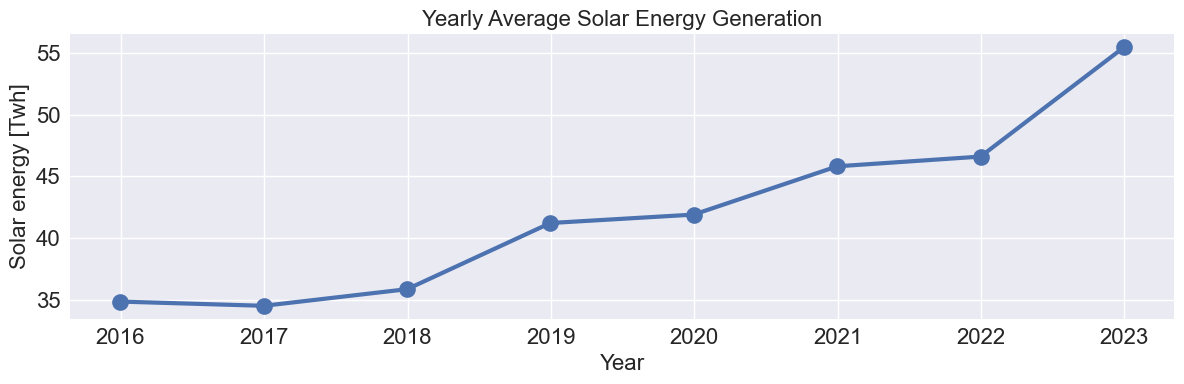

In [1863]:


# Convert the 'Date' column to datetimdata_df_solar_N['Date'] = pd.to_datetime(data_df_solar_N['Date'])

# Group data by the specified time interval (Year)
grouped = data_df_solar_N.groupby(pd.Grouper(key='Date', freq='Y'))['Solar_Twh'].sum().reset_index()

# Exclude the last point
grouped = grouped.iloc[:-1]

# Set plot style
sns.set(style="whitegrid")

# Set plot style
plt.style.use('seaborn')

# Create the plot
plt.figure(figsize=(12, 4))
plt.plot(grouped['Date'], grouped['Solar_Twh'], marker='o', color='b', markersize=12, linewidth=3)
plt.xlabel('Year', fontsize=16)  # Increase font size of x-axis label
plt.ylabel('Solar energy [Twh]', fontsize=16)  # Increase font size of y-axis label
plt.title('Yearly Average Solar Energy Generation', fontsize=16)  # Increase font size of title
#plt.xticks(rotation=45, fontsize=10)  # Increase font size of x-axis tick labels
plt.yticks(fontsize=16)  # Increase font size of y-axis tick labels
plt.xticks(fontsize=16)  # Increase font size of y-axis tick labels
#ax.tick_params(axis='both', which='both', labelsize=14)
plt.grid(True)
plt.gca().spines['top'].set_visible(False)  # Hide top spine
plt.gca().spines['right'].set_visible(False)  # Hide right spine

# Show the plot
plt.tight_layout()
plt.show()


In [1864]:
#plot_yearly_average(target='Solar_Twh', data_df= data_df_twh, y_values='Solar_Twh', x='Date', time='Year', titlem ='', ylabely = 'Solar energy generation [Twh]')


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_29835/2956015616.py:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


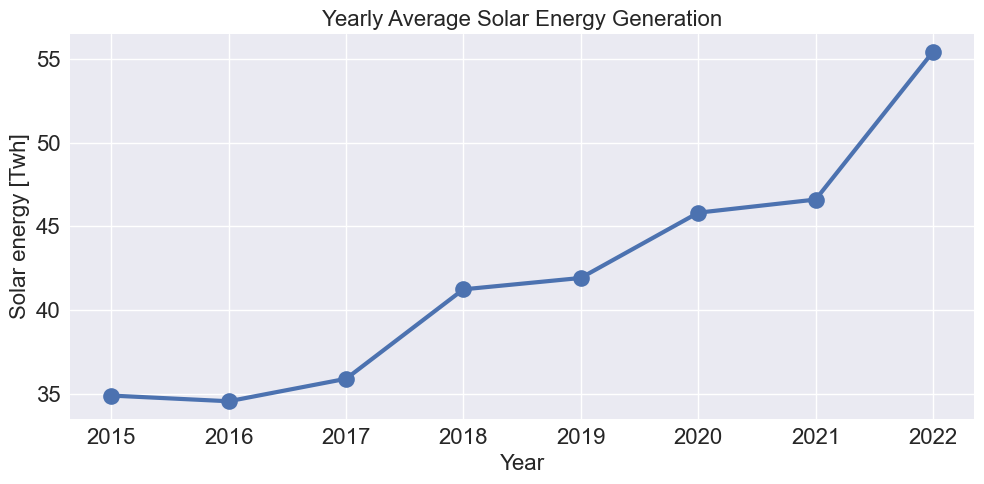

In [1865]:
# Convert the 'Date' column to datetime
data_df_solar_N['Date'] = pd.to_datetime(data_df_solar_N['Date'])

# Group data by the specified time interval (Year)
grouped = data_df_solar_N.groupby(pd.Grouper(key='Date', freq='Y'))['Solar_Twh'].sum().reset_index()

# Exclude the last point
grouped = grouped.iloc[:-1]

# Set plot style
sns.set(style="white")

# Set plot style
plt.style.use('seaborn')

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(grouped['Date'], grouped['Solar_Twh'], marker='o', color='b', markersize=12, linewidth=3)
plt.xlabel('Year', fontsize=16)  # Increase font size of x-axis label
plt.ylabel('Solar energy [Twh]', fontsize=16)  # Increase font size of y-axis label
plt.title('Yearly Average Solar Energy Generation', fontsize=16)  # Increase font size of title
plt.xticks(fontsize=16)  # Increase font size of x-axis tick labels
plt.yticks(fontsize=16)  # Increase font size of y-axis tick labels
#ax.tick_params(axis='both', which='both', labelsize=14)
plt.grid(True)  # Remove grid
plt.gca().spines['top'].set_visible(False)  # Hide top spine
plt.gca().spines['right'].set_visible(False)  # Hide right spine

# Customize x-axis tick labels
custom_xticks = ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']
plt.xticks(grouped['Date'], custom_xticks)

# Show the plot
plt.tight_layout()
plt.show()


In [1866]:
 data_df_twh.shape

(74879, 33)

In [1867]:
 data_df_twh_cp =  data_df_twh.copy()

In [1868]:
 data_df_twh_cp.shape

(74879, 33)

In [1869]:
 clmn = ['Date', 'Solar_Twh', 'Total_energy_generation_Twh']
 data_df_twh_cp_N =   data_df_twh_cp[ clmn].copy()

In [1870]:
 data_df_twh_cp_N.head()

,Date,Solar_Twh,Total_energy_generation_Twh
0,2015-01-01,0.0,0.051459
1,2015-01-01,0.0,0.049988
2,2015-01-01,0.0,0.049265
3,2015-01-01,0.0,0.048538
4,2015-01-01,0.0,0.048630


Date
2015    34.879418
2016    34.538936
2017    35.883181
2018    41.234283
2019    41.914770
2020    45.821578
2021    46.606885
2022    55.440975
2023    33.656714
Name: Solar_Twh, dtype: float64 Date
2015    540.576609
2016    545.848951
2017    551.709086
2018    547.083723
2019    524.282537
2020    496.400644
2021    505.053662
2022    493.369202
2023    249.807735
Name: Total_energy_generation_Twh, dtype: float64
Index([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023], dtype='int32', name='Date') Date
2015     6.452262
2016     6.327563
2017     6.504004
2018     7.537107
2019     7.994691
2020     9.230765
2021     9.228105
2022    11.237218
2023    13.473047
Name: Proportion, dtype: float64


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_29835/3250876021.py:16: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


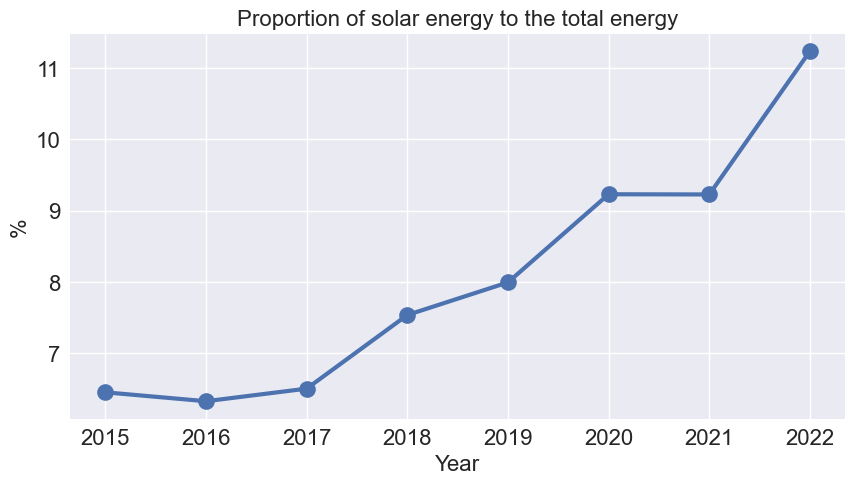

In [1871]:
# Assuming 'Date' column is already in datetime format
data_df_twh_cp_N['Date'] = pd.to_datetime(data_df_twh_cp_N['Date'])

# Group data by the year and calculate the yearly sum of solar and total energy
grouped = data_df_twh_cp_N.groupby(data_df_twh_cp_N['Date'].dt.year)[['Solar_Twh', 'Total_energy_generation_Twh']].sum()

#print(grouped, grouped['Solar_Twh'], grouped['Total_energy_generation_Twh'])
print(grouped['Solar_Twh'], grouped['Total_energy_generation_Twh'])
# Calculate the yearly average proportion of solar energy
grouped['Proportion'] = (grouped['Solar_Twh']/ grouped['Total_energy_generation_Twh']) * 100
#print(grouped['Solar_Twh'], grouped['Total_energy_generation_Twh'], grouped['Solar_Twh'] / grouped['Total_energy_generation_Twh'], 540.576609/34.879418)
print(grouped.index, grouped['Proportion'])
grouped = grouped.iloc[:-1]
# Set plot style
sns.set(style="whitegrid")
plt.style.use('seaborn')
# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(grouped.index, grouped['Proportion'], marker='o', color='b', markersize=12, linewidth=3)
plt.xlabel('Year', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.title('Proportion of solar energy to the total energy', fontsize=16)  # Increase font size of title
plt.yticks(fontsize=16)  # Increase font size of y-axis tick labels
plt.xticks(fontsize=16)  # Increase font size of y-axis tick labels
#plt.title('Yearly Average Proportion of Solar Energy')
#plt.xticks(grouped.index, rotation=45)
plt.grid(True)
plt.gca().spines['top'].set_visible(False)  # Hide top spine
plt.gca().spines['right'].set_visible(False)  # Hide right spine
plt.show()

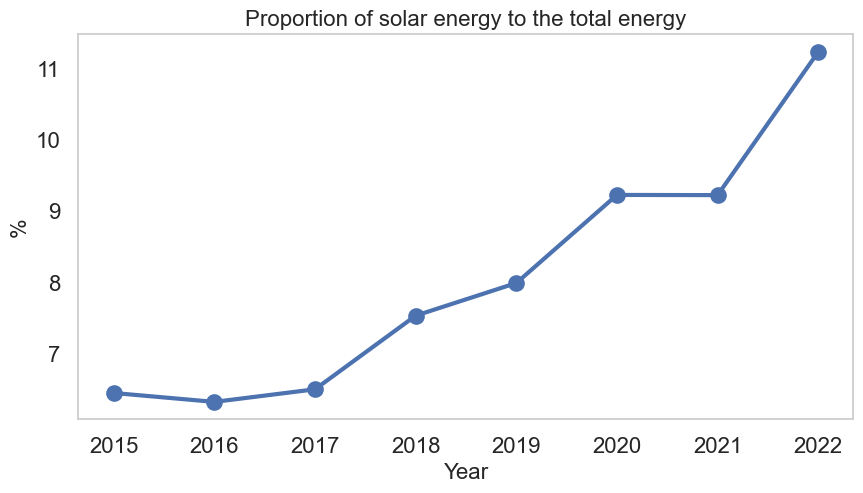

In [1931]:

# Assuming 'Date' column is already in datetime format
data_df_twh_cp_N['Date'] = pd.to_datetime(data_df_twh_cp_N['Date'])

# Group data by the year and calculate the yearly sum of solar and total energy
grouped = data_df_twh_cp_N.groupby(data_df_twh_cp_N['Date'].dt.year)[['Solar_Twh', 'Total_energy_generation_Twh']].sum()

# Calculate the yearly average proportion of solar energy
grouped['Proportion'] = (grouped['Solar_Twh'] / grouped['Total_energy_generation_Twh']) * 100
grouped = grouped.iloc[:-1]

# Set plot style
#sns.set(style="white")
sns.set(style="whitegrid")
    
#plt.style.use('seaborn')

# Create the plot with white background and no grid
plt.figure(figsize=(10, 5))
plt.plot(grouped.index, grouped['Proportion'], marker='o', color='b', markersize=12, linewidth=3)
plt.xlabel('Year', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.title('Proportion of solar energy to the total energy', fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(grouped.index, grouped.index, fontsize=16)  # Use the year values for x-axis ticks
plt.grid(False)  # Turn off the grid
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)

# Save the figure with transparent background
#plt.savefig('proportion_plot.png', bbox_inches='tight', transparent=True)
plt.show()



/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_29835/3453955031.py:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


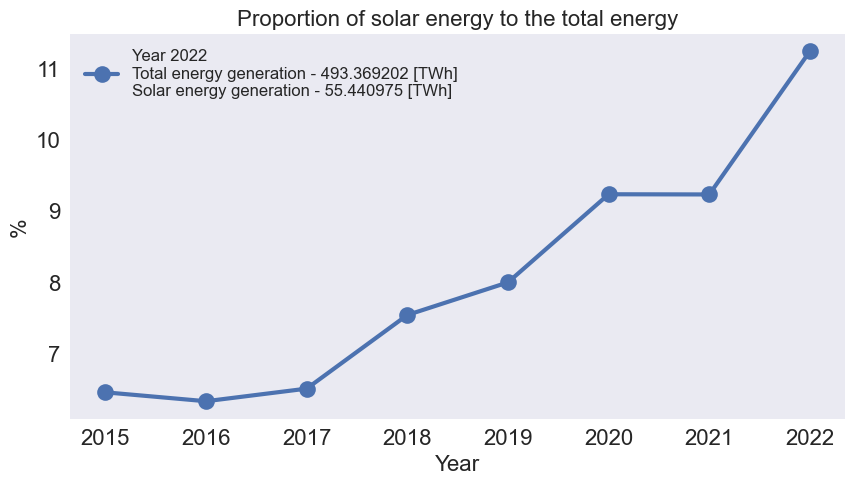

In [1934]:


# Assuming 'Date' column is already in datetime format
data_df_twh_cp_N['Date'] = pd.to_datetime(data_df_twh_cp_N['Date'])

# Group data by the year and calculate the yearly sum of solar and total energy
grouped = data_df_twh_cp_N.groupby(data_df_twh_cp_N['Date'].dt.year)[['Solar_Twh', 'Total_energy_generation_Twh']].sum()

# Calculate the yearly average proportion of solar energy
grouped['Proportion'] = (grouped['Solar_Twh'] / grouped['Total_energy_generation_Twh']) * 100
grouped = grouped.iloc[:-1]

# Set plot style
sns.set(style="white")
plt.style.use('seaborn')

# Create the plot with white background and no grid
plt.figure(figsize=(10, 5))
plt.plot(grouped.index, grouped['Proportion'], marker='o', color='b', markersize=12, linewidth=3)
plt.xlabel('Year', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.title('Proportion of solar energy to the total energy', fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(grouped.index, grouped.index, fontsize=16)  # Use the year values for x-axis ticks
plt.grid(False)  # Turn off the grid
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)

# Add legend
legend_text = (
    "Year 2022\n"
    "Total energy generation - 493.369202 [TWh]\n"
    "Solar energy generation - 55.440975 [TWh]"
)
plt.legend([legend_text], loc='upper left', fontsize=12)

# Save the figure with transparent background
# plt.savefig('proportion_plot.png', bbox_inches='tight', transparent=True)
plt.show()


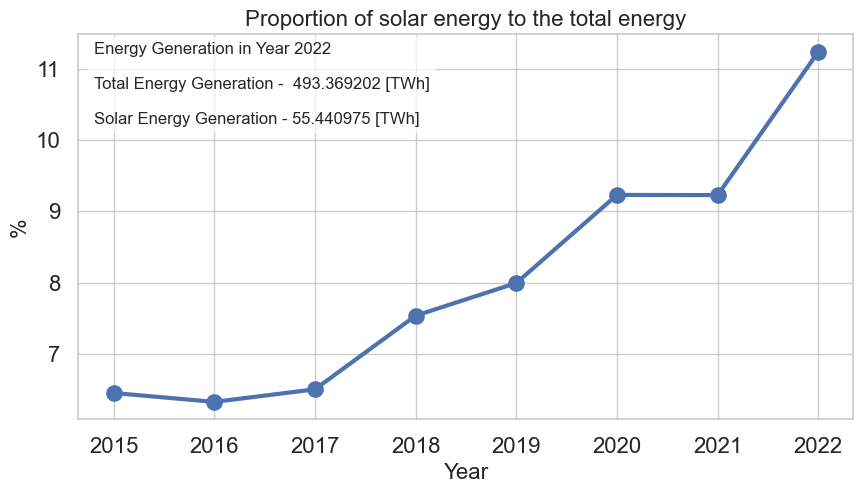

In [1949]:


# Assuming 'Date' column is already in datetime format
data_df_twh_cp_N['Date'] = pd.to_datetime(data_df_twh_cp_N['Date'])

# Group data by the year and calculate the yearly sum of solar and total energy
grouped = data_df_twh_cp_N.groupby(data_df_twh_cp_N['Date'].dt.year)[['Solar_Twh', 'Total_energy_generation_Twh']].sum()

# Calculate the yearly average proportion of solar energy
grouped['Proportion'] = (grouped['Solar_Twh'] / grouped['Total_energy_generation_Twh']) * 100
grouped = grouped.iloc[:-1]

# Set plot style
#sns.set(style="white")
#plt.style.use('seaborn')
sns.set(style="whitegrid")

# Create the plot with white background and no grid
plt.figure(figsize=(10, 5))
plt.plot(grouped.index, grouped['Proportion'], marker='o', color='b', markersize=12, linewidth=3)
plt.xlabel('Year', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.title('Proportion of solar energy to the total energy', fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(grouped.index, grouped.index, fontsize=16)  # Use the year values for x-axis ticks
plt.grid(True)  # Turn off the grid
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)

# Add the information as a box with spaces between lines
info_text = (
    "Energy Generation in Year 2022\n\n"
    "Total Energy Generation -  493.369202 [TWh]\n\n"
    "Solar Energy Generation - 55.440975 [TWh]"
)
plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

# Save the figure with transparent background
# plt.savefig('proportion_plot.png', bbox_inches='tight', transparent=True)
plt.show()


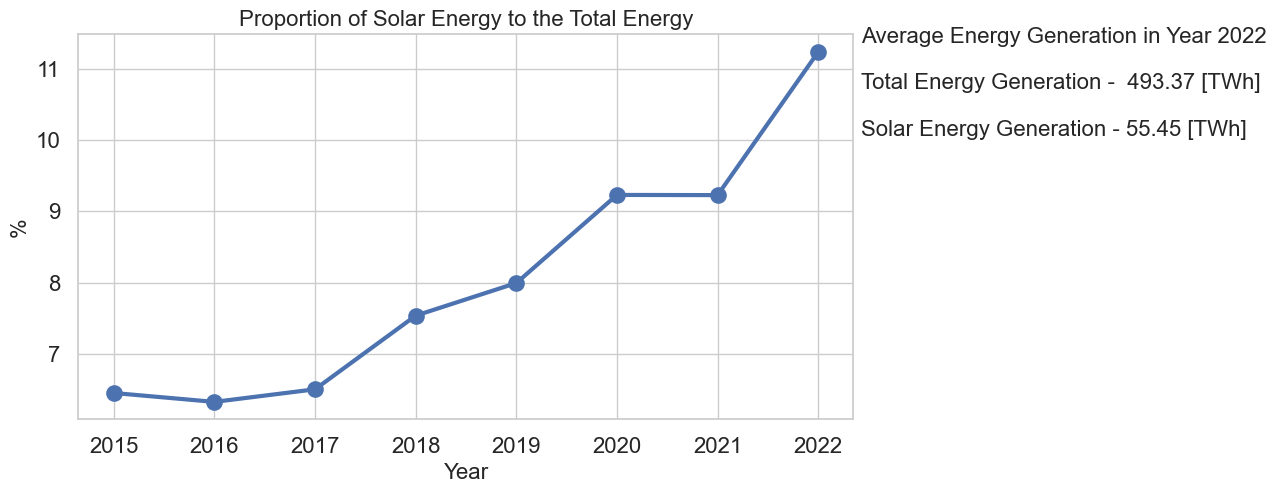

In [1965]:


# Assuming 'Date' column is already in datetime format
data_df_twh_cp_N['Date'] = pd.to_datetime(data_df_twh_cp_N['Date'])

# Group data by the year and calculate the yearly sum of solar and total energy
grouped = data_df_twh_cp_N.groupby(data_df_twh_cp_N['Date'].dt.year)[['Solar_Twh', 'Total_energy_generation_Twh']].sum()

# Calculate the yearly average proportion of solar energy
grouped['Proportion'] = (grouped['Solar_Twh'] / grouped['Total_energy_generation_Twh']) * 100
grouped = grouped.iloc[:-1]

# Set plot style
#sns.set(style="white")
#plt.style.use('seaborn')
sns.set(style="whitegrid")

# Create the plot with white background and no grid
plt.figure(figsize=(10, 5))
plt.plot(grouped.index, grouped['Proportion'], marker='o', color='b', markersize=12, linewidth=3)
plt.xlabel('Year', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.title('Proportion of Solar Energy to the Total Energy', fontsize=16)
plt.yticks(fontsize=18)
plt.xticks(grouped.index, grouped.index, fontsize=16)  # Use the year values for x-axis ticks
plt.grid(True)  # Turn off the grid
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)

# Show ticks corresponding to the displayed numbers
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Add the information as a box with spaces between lines outside the frame on top right
info_text = (
    "Average Energy Generation in Year 2022\n\n"
    "Total Energy Generation -  493.37 [TWh]\n\n"
    "Solar Energy Generation - 55.45 [TWh]"
)
plt.text(1.01, 1.02, info_text, transform=plt.gca().transAxes, fontsize=16,
         verticalalignment='top', horizontalalignment='left', bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

# Save the figure with transparent background
# plt.savefig('proportion_plot.png', bbox_inches='tight', transparent=True)
plt.show()


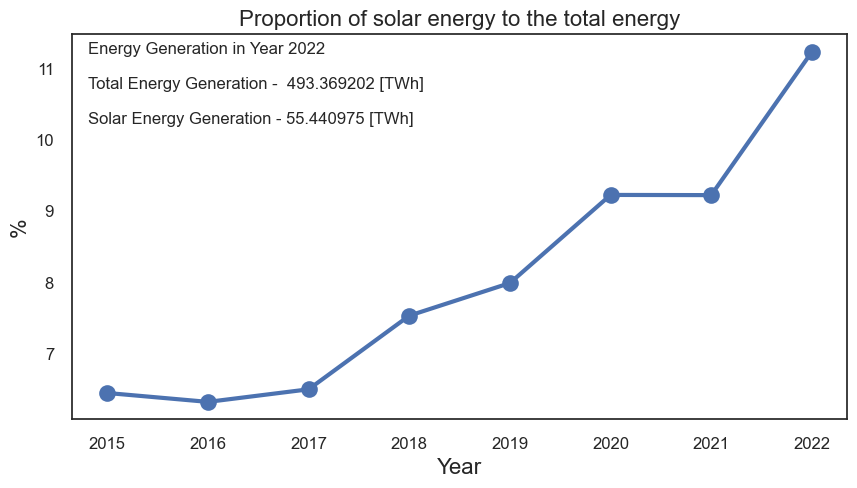

In [1947]:
# Assuming 'Date' column is already in datetime format
data_df_twh_cp_N['Date'] = pd.to_datetime(data_df_twh_cp_N['Date'])

# Group data by the year and calculate the yearly sum of solar and total energy
grouped = data_df_twh_cp_N.groupby(data_df_twh_cp_N['Date'].dt.year)[['Solar_Twh', 'Total_energy_generation_Twh']].sum()

# Calculate the yearly average proportion of solar energy
grouped['Proportion'] = (grouped['Solar_Twh'] / grouped['Total_energy_generation_Twh']) * 100
grouped = grouped.iloc[:-1]

# Set plot style
sns.set(style="white")
#plt.style.use('seaborn')
#sns.set(style="whitegrid")

# Create the plot with white background and no grid
plt.figure(figsize=(10, 5))
plt.plot(grouped.index, grouped['Proportion'], marker='o', color='b', markersize=12, linewidth=3)
plt.xlabel('Year', fontsize=16)
plt.ylabel('%', fontsize=16)
plt.title('Proportion of solar energy to the total energy', fontsize=16)
plt.yticks(fontsize=16)
plt.xticks(grouped.index, grouped.index, fontsize=16)  # Use the year values for x-axis ticks
plt.grid(False)  # Turn off the grid
plt.gca().spines['top'].set_visible(True)
plt.gca().spines['right'].set_visible(True)

# Add the information as a box with spaces between lines
info_text = (
    "Energy Generation in Year 2022\n\n"
    "Total Energy Generation -  493.369202 [TWh]\n\n"
    "Solar Energy Generation - 55.440975 [TWh]"
)
plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

# Show ticks corresponding to the displayed numbers
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Save the figure with transparent background
# plt.savefig('proportion_plot.png', bbox_inches='tight', transparent=True)
plt.show()


In [1921]:
 #data_df_twh['TEnergybySolar_twh'] =   (data_df_twh['Solar_Twh']/data_df_twh['Total_energy_generation_Twh'])*100.

<Axes: xlabel='Date', ylabel='TEnergybySolar_twh'>

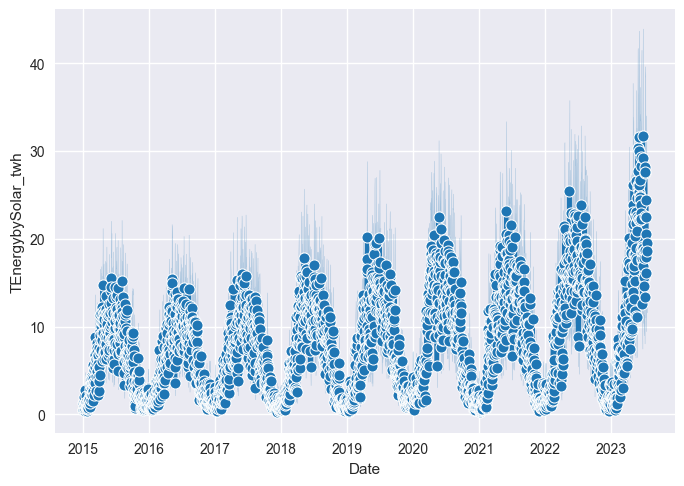

In [1873]:
sns.lineplot(data= data_df_twh, x='Date', y='TEnergybySolar_twh', color='#1f76b4', linewidth=3, marker='o', markersize=8)

#### Ratio 

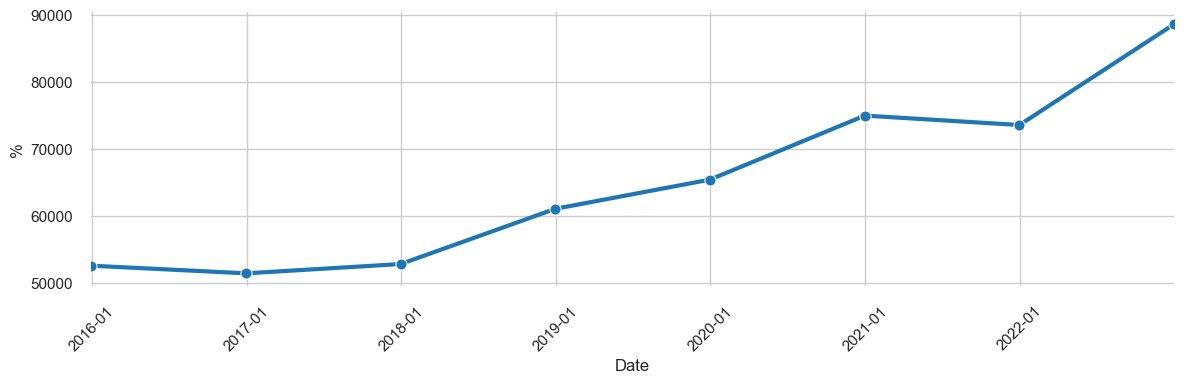

In [1874]:
plot_yearly_ratio(target='TEnergybySolar_twh', data_df= data_df_twh, y_values='TEnergybySolar_twh', x='Date', time='Year', titlem ='', ylabely = '%')

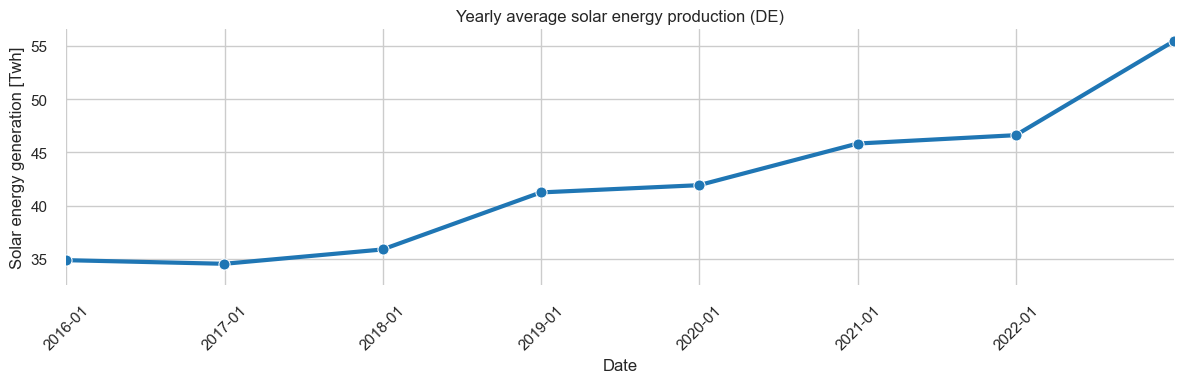

In [1875]:
#plot_yearly_average(target='Total_energy_generation_gwh', data_df= data_df, y_values='Total_energy_generation_gwh', x='Date', time='Year')
plot_yearly_average(target='Solar_Twh', data_df= data_df_twh, y_values='Solar_Twh', x='Date', time='Month', titlem ='Yearly average solar energy production (DE)', ylabely = 'Solar energy generation [Twh]')


In [1920]:
#plot_yearly_average(target='Total_energy_generation_gwh', data_df= data_df, y_values='Total_energy_generation_gwh', x='Date', time='Year')
#plot_yearly_average(target='Solar_gwh', data_df= data_df, y_values='Solar_gwh', x='Date', time='Month', titlem ='Yearly average solar energy production (DE)', ylabely = 'Solar energy generation [Gwh]')


In [1919]:

#plot_yearly_average(target='Solar_gwh', data_df= data_df, y_values='Solar_gwh', x='Date', time='Year', titlem ='Yearly average solar energy production (DE)', ylabely = 'Solar energy generation [Gwh]')
#plot_yearly_average(target='Total_energy_generation_Twh', data_df= data_df_twh, y_values='Total_energy_generation_Twh', x='Date', time='Year'   
#    ,titlem ='Yearly average total energy production (DE)', ylabely = 'Total energy generation [Twh]')

In [1918]:

#plot_yearly_average(target='Solar_gwh', data_df= data_df, y_values='Solar_gwh', x='Date', time='Year', titlem ='Yearly average solar energy production (DE)', ylabely = 'Solar energy generation [Gwh]')
#plot_yearly_average(target='Total_energy_generation_gwh', data_df= data_df, y_values='Total_energy_generation_gwh', x='Date', time='Year'   
#    ,titlem ='Yearly average total energy production (DE)', ylabely = 'Total energy generation [Gwh]')



#### Monthly average

In [1879]:

def plot_monthly_average(target, data_df, y_values, x='Date', time='Month', titlem ='Yearly average  solar energy production (DE)', ylabely = 'Solar energy generation (Gwh)'):
    # Convert the 'Date' column to datetime
    data_df['Date'] = pd.to_datetime(data_df['Date'])
    
    # Group data by the specified time interval (Year)
    grouped = data_df.groupby(pd.Grouper(key='Date', freq='M'))[target].sum().reset_index()
    
    #print(grouped, grouped.shape)
    # Set plot style
    sns.set(style="whitegrid")
    
    # Create the plot
    #print(grouped[0:12], data_df[x], data_df[y_values])

    fig, ax = plt.subplots(figsize=(15,5))
    #plt.figure(figsize=(10, 6))
    #ax = sns.lineplot(data=grouped, x=x, y=y_values, color='#1f76b4', linewidth=4, marker='o', markersize=8, markeredgewidth=8)
    ax = sns.lineplot(data=grouped, x=x, y=y_values, color='#1f76b4', linewidth=3, marker='o', markersize=8)
    plt.xlabel('Date')
    plt.ylabel(ylabely)#('Solar energy generation (Gwh)')
    plt.title(titlem)#('Yearly average  solar energy production (DE)')    
    # Set x-axis date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
    # Set x-axis limits based on data range
    start_date = pd.Timestamp('2015-12-31')
    end_date = pd.Timestamp('2022-12-31')

    plt.xlim(start_date, end_date)
    #plt.ylim(30000,55000)
    #plt.ylim(30,55)
    # Show the plot
    plt.tight_layout()
    #sns.despine()
    # Remove top, right, and bottom spines (frame) of the plot
    sns.despine(top=True, right=True, left=True, bottom=True)
    plt.show()

    ## Energy development over year (time)
    #fig, ax = plt.subplots()
    #sns.lineplot(data=grouped, x=x, y=y_values, marker='o', color='#1f76b4')
    #ax.set(title='Yearly average  solar energy production (DE', ylabel= 'Solar energy generation (Gwh)', xlabel = 'Year');


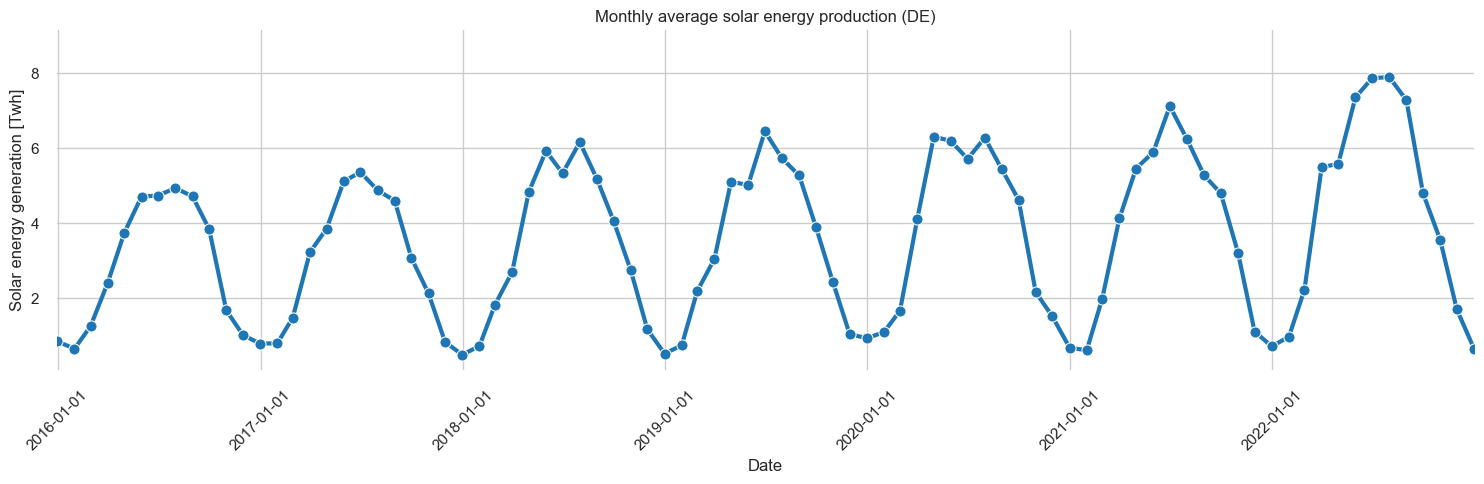

In [1880]:
plot_monthly_average(target='Solar_Twh', data_df= data_df_twh, y_values='Solar_Twh', x='Date', time='Month', titlem ='Monthly average solar energy production (DE)', ylabely = 'Solar energy generation [Twh]')


In [1917]:

#plot_monthly_average(target='Solar_gwh', data_df= data_df, y_values='Solar_gwh', x='Date', time='Month', titlem ='Monthly average solar energy production (DE)', ylabely = 'Solar energy generation [Gwh]')


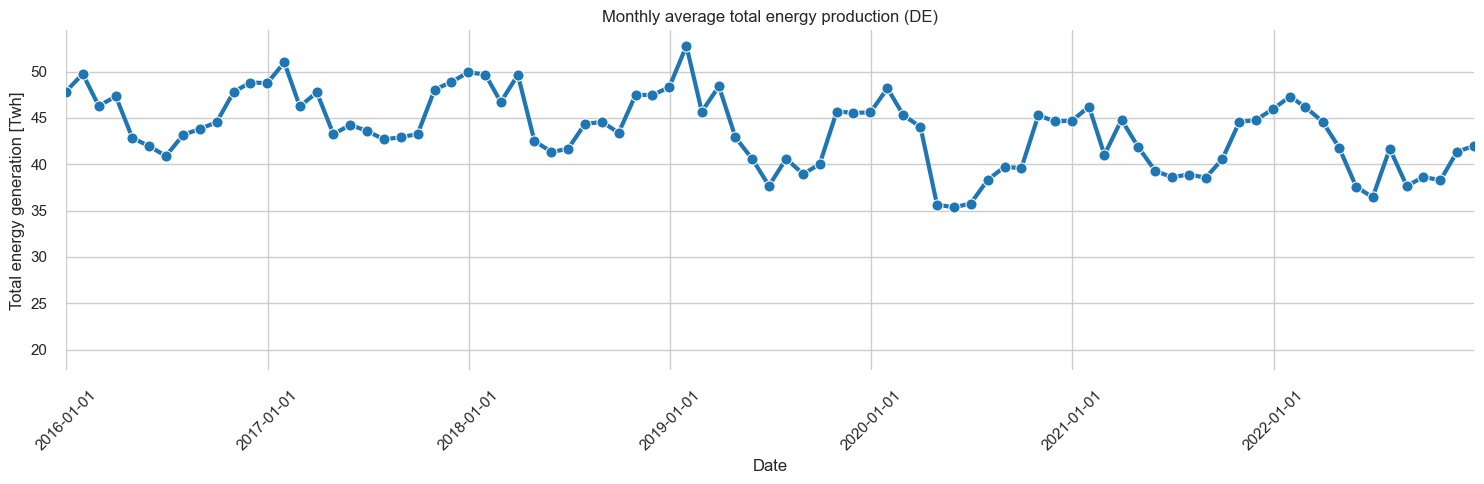

In [1882]:
plot_monthly_average(target='Total_energy_generation_Twh', data_df= data_df_twh, y_values='Total_energy_generation_Twh', x='Date', time='Year'   
    ,titlem ='Monthly average total energy production (DE)', ylabely = 'Total energy generation [Twh]')

In [1916]:
#plot_monthly_average(target='Total_energy_generation_gwh', data_df= data_df, y_values='Total_energy_generation_gwh', x='Date', time='Year'   
   # ,titlem ='Monthly average total energy production (DE)', ylabely = 'Total energy generation [Gwh]')

## Energy resources

In [1884]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [1885]:
data_df['Total_other_renewable_gwh_N'] =  data_df['Waste_gwh']+ data_df['Other_renewable_gwh'] + data_df['Marine_gwh'] + data_df['Hydro_run_of_river_and_poundage_gwh'] + data_df['Hydro_water_reservoir_gwh'] + data_df['Geothermal_gwh']
data_df['Total_Fossil_gwh_N'] = data_df['Fossil_brown_coal_gwh'] + data_df['Fossil_coal_derived_gas_gwh']+ data_df['Fossil_gas_gwh']+ data_df['Fossil_hard_coal_gwh']+ data_df['Fossil_oil_gwh']+ data_df['Fossil_oil_shale_gwh']+ data_df['Fossil_peat_gwh']
data_df.head()

#['Total_other_renewable_gwh_N', 'Total_Fossil_gwh_N', 'Nuclear_gwh']

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear,Total_other_renewable_gwh_N,Total_Fossil_gwh_N
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,51.45925,0.0,51.45925,9.66900,2015,1,1,1,1.5895,20.30975
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,49.98825,0.0,49.98825,9.86225,2015,1,1,1,1.6055,18.71825
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,49.26525,0.0,49.26525,10.00325,2015,1,1,1,1.5205,18.02675
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,48.53800,0.0,48.53800,9.97275,2015,1,1,1,1.5125,17.40900
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,48.63000,0.0,48.63000,10.03125,2015,1,1,1,1.5015,17.58200


In [1886]:
data_dfN = data_df.copy()

In [1887]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear,Total_other_renewable_gwh_N,Total_Fossil_gwh_N
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,51.45925,0.0,51.45925,9.66900,2015,1,1,1,1.5895,20.30975
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,49.98825,0.0,49.98825,9.86225,2015,1,1,1,1.6055,18.71825
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,49.26525,0.0,49.26525,10.00325,2015,1,1,1,1.5205,18.02675
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,48.53800,0.0,48.53800,9.97275,2015,1,1,1,1.5125,17.40900
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,48.63000,0.0,48.63000,10.03125,2015,1,1,1,1.5015,17.58200


In [1888]:
data_dfN.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear,Total_other_renewable_gwh_N,Total_Fossil_gwh_N
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,51.45925,0.0,51.45925,9.66900,2015,1,1,1,1.5895,20.30975
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,49.98825,0.0,49.98825,9.86225,2015,1,1,1,1.6055,18.71825
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,49.26525,0.0,49.26525,10.00325,2015,1,1,1,1.5205,18.02675
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,48.53800,0.0,48.53800,9.97275,2015,1,1,1,1.5125,17.40900
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,48.63000,0.0,48.63000,10.03125,2015,1,1,1,1.5015,17.58200


In [1897]:
data_dfN1 = data_df.copy()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


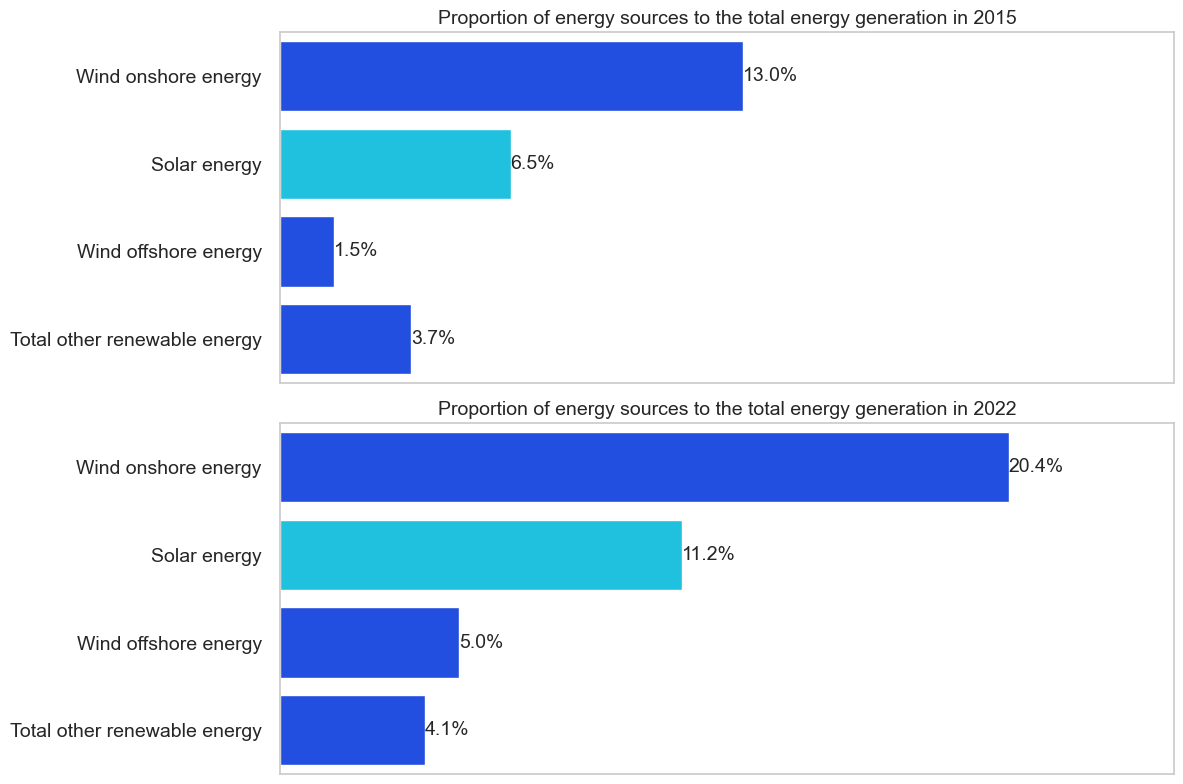

In [1911]:
# Assuming 'Date' column is already in datetime format
data_dfN1['Date'] = pd.to_datetime(data_dfN1['Date'])

# Extract year and create masks for the years 2015 and 2022
data_dfN1['Year'] = data_dfN1['Date'].dt.year
mask_2015 = data_dfN1['Year'] == 2015
mask_2022 = data_dfN1['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_dfN1[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_dfN1[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Calculate the total energy generated for each year
total_energy_2015 = data_dfN1[mask_2015]['Total_energy_generation_gwh'].sum()
total_energy_2022 = data_dfN1[mask_2022]['Total_energy_generation_gwh'].sum()

# Calculate the percentage contribution of each energy source
data_2015_grouped_percentage = data_2015_grouped.copy()
data_2022_grouped_percentage = data_2022_grouped.copy()

for column in columns_to_plot:
    data_2015_grouped_percentage[column] = (data_2015_grouped_percentage[column] / total_energy_2015) * 100
    data_2022_grouped_percentage[column] = (data_2022_grouped_percentage[column] / total_energy_2022) * 100

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped_percentage.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Percentage')
data_2022_grouped_melted = data_2022_grouped_percentage.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Percentage')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Color palette
#custom_palette = sns.color_palette("Set2", n_colors=len(columns_to_plot))
custom_palette = [sns.color_palette("bright")[0]] * 1 + [sns.color_palette("bright")[-1]] + [sns.color_palette("bright")[0]] * 3

# Energy source labels
energy_source_labels = {
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
#ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Percentage', hue='Date', orient='h', palette=custom_palette)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Percentage', palette=custom_palette)
ax1.set_title('Proportion of energy sources to the total energy generation in 2015', fontsize=14)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_xlim(0, 25)
ax1.set_xticks([])
ax1.legend().set_visible(False)

# Replace y-labels
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()], fontsize=14)

# Annotate bars with the percentage
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=14)

# Plot for 2022
plt.subplot(2, 1, 2)
#ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Percentage', hue='Date', orient='h', palette=custom_palette)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Percentage', palette=custom_palette)
ax2.set_title('Proportion of energy sources to the total energy generation in 2022', fontsize=14)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_xlim(0, 25)
ax2.set_xticks([])
ax2.legend().set_visible(False)

# Replace y-labels
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()], fontsize=14)

# Annotate bars with the percentage
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=14)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


In [1914]:
data_dfN1 = data_df.copy()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


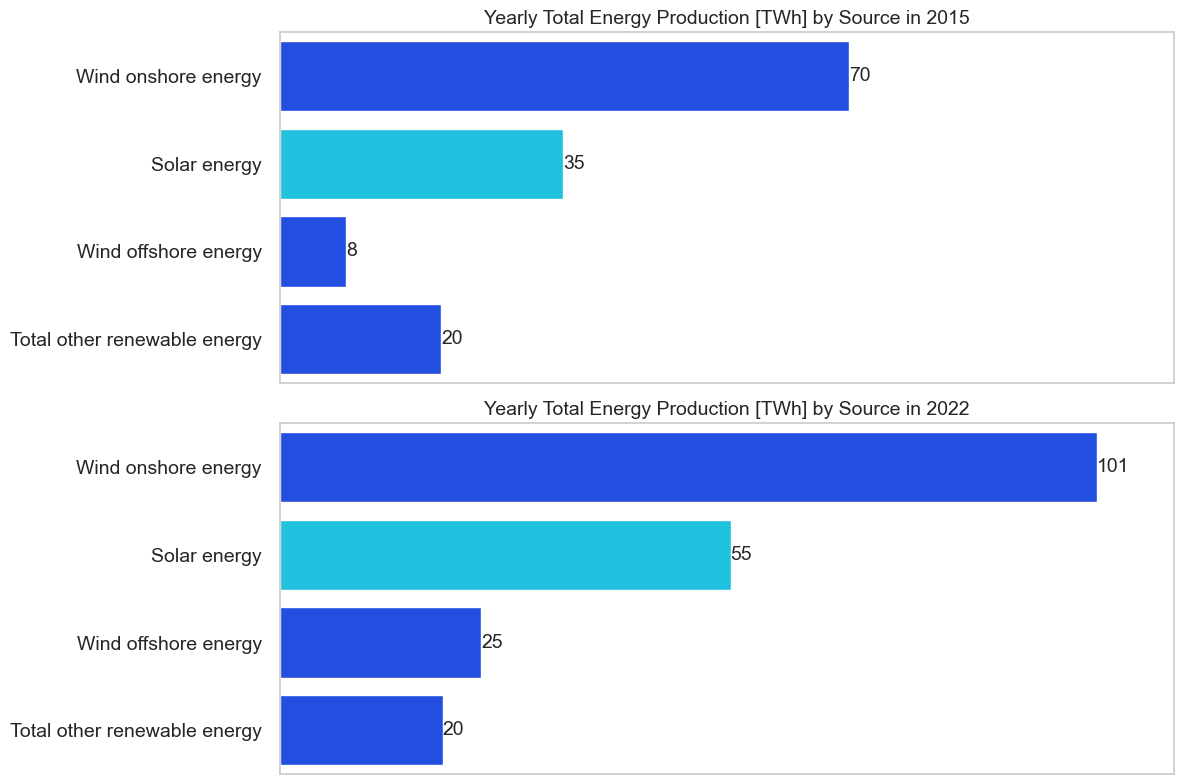

In [1915]:

# Assuming 'Date' column is already in datetime format
data_dfN1['Date'] = pd.to_datetime(data_dfN1['Date'])

# Convert energy values in GWh columns to TWh
energy_columns = ['Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
data_dfN1[energy_columns] = data_dfN1[energy_columns] / 1000.  # Convert GWh to TWh

# Extract year and create masks for the years 2015 and 2022
data_dfN1['Year'] = data_dfN1['Date'].dt.year
mask_2015 = data_dfN1['Year'] == 2015
mask_2022 = data_dfN1['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_dfN1[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()
data_2022_grouped = data_dfN1[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Single color for all energy except 'Solar energy'
energy_colors =  [sns.color_palette("bright")[0]] * 1 + [sns.color_palette("bright")[-1]] + [sns.color_palette("bright")[0]] * 3#[sns.color_palette("bright")[0]] * 2 + [sns.color_palette("bright")[-1]]

# Energy Source labels mapping
energy_source_labels = {
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax1.set_title('Yearly Total Energy Production [TWh] by Source in 2015', fontsize=14)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()], fontsize=14)  # Update y-axis labels
#ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.set_xlim(0, 110)
ax1.legend().set_visible(False)
ax1.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=14)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax2.set_title('Yearly Total Energy Production [TWh] by Source in 2022', fontsize=14)
#ax2.set_xlabel('Total Energy (TWh)')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()], fontsize=14)  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.set_xlim(0, 110)
ax2.legend().set_visible(False)
ax2.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=14)
ax1.grid(False)
ax2.grid(False)
# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


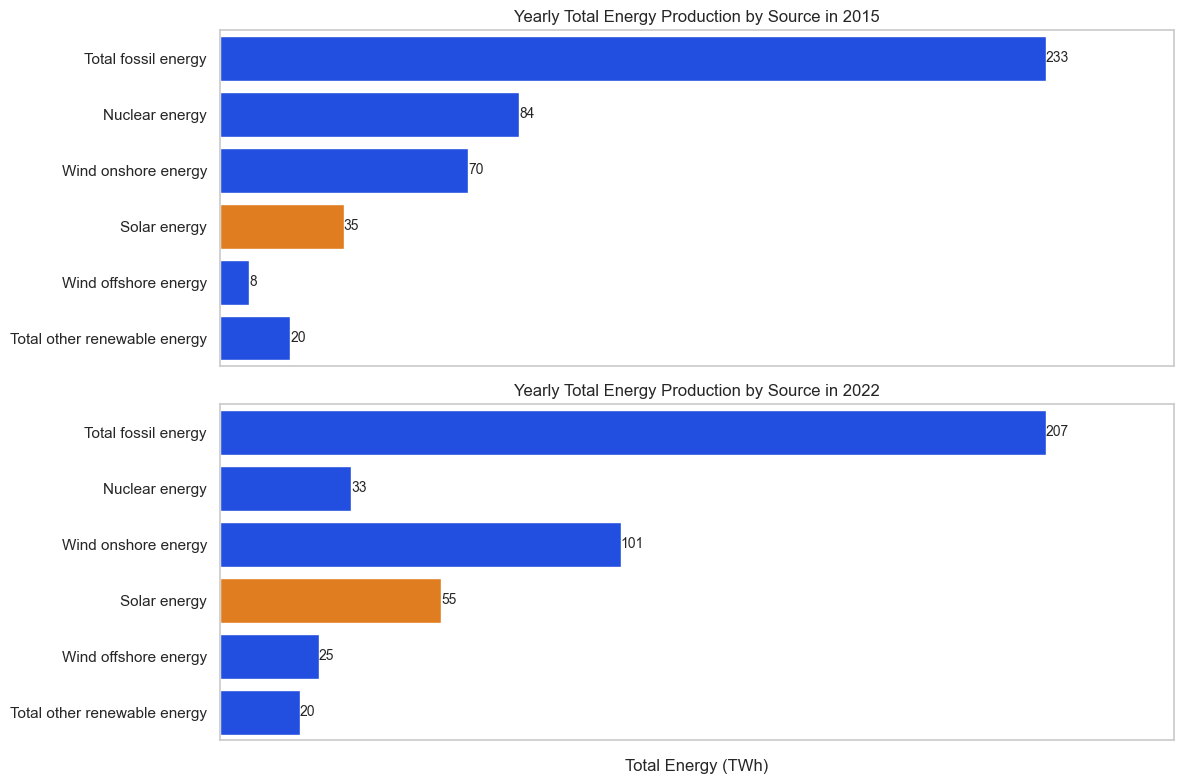

In [958]:

# Assuming 'Date' column is already in datetime format
data_dfN['Date'] = pd.to_datetime(data_dfN['Date'])

# Convert energy values in GWh columns to TWh
energy_columns = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
data_dfN[energy_columns] = data_dfN[energy_columns] / 1000.  # Convert GWh to TWh

# Extract year and create masks for the years 2015 and 2022
data_dfN['Year'] = data_dfN['Date'].dt.year
mask_2015 = data_dfN['Year'] == 2015
mask_2022 = data_dfN['Year'] == 2022

# Columns to plot
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_dfN[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()
data_2022_grouped = data_dfN[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Single color for all energy except 'Solar energy'
energy_colors = [sns.color_palette("bright")[0]] * 3 + [sns.color_palette("bright")[1]]

# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax1.set_title('Yearly Total Energy Production by Source in 2015')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)
ax1.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax2.set_title('Yearly Total Energy Production by Source in 2022')
#ax2.set_xlabel('Total Energy (TWh)')
ax2.set_xlabel('Total Energy (TWh)')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)
ax2.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

ax1.grid(False)
ax2.grid(False)
# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


In [959]:
data_dfN1 = data_df.copy()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


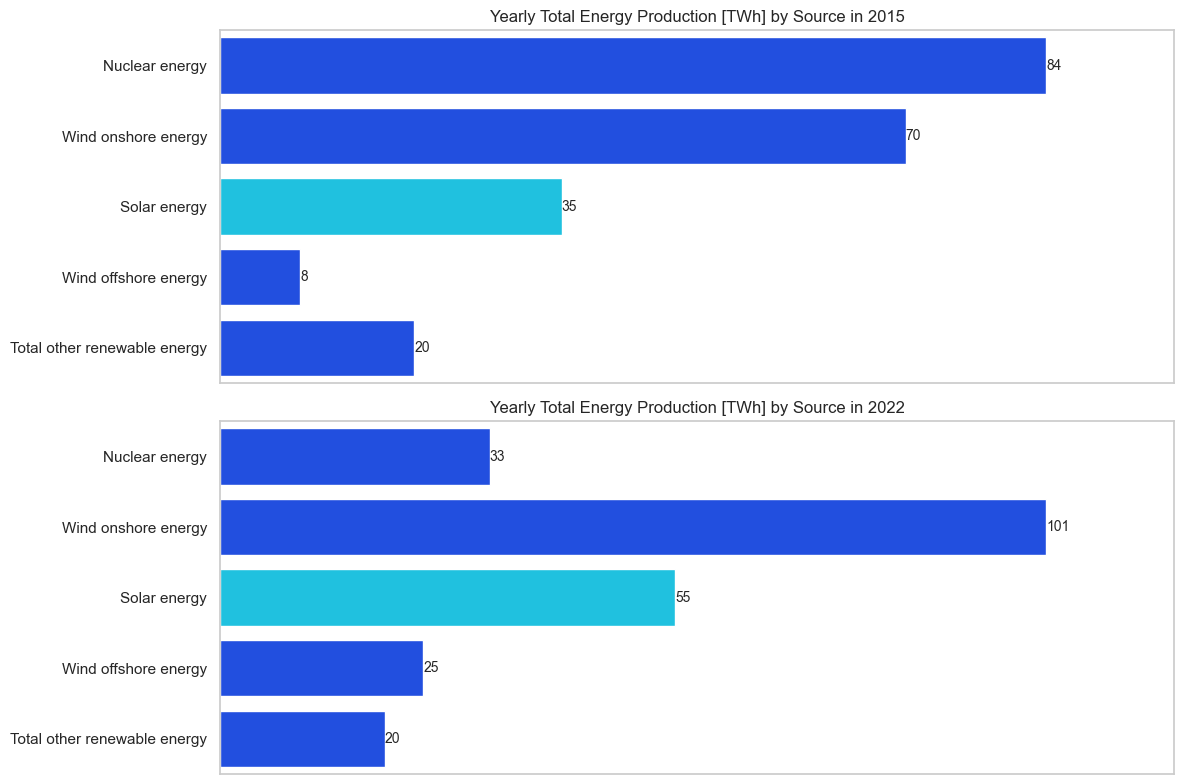

In [960]:

# Assuming 'Date' column is already in datetime format
data_dfN1['Date'] = pd.to_datetime(data_dfN1['Date'])

# Convert energy values in GWh columns to TWh
energy_columns = ['Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
data_dfN1[energy_columns] = data_dfN1[energy_columns] / 1000.  # Convert GWh to TWh

# Extract year and create masks for the years 2015 and 2022
data_dfN1['Year'] = data_dfN1['Date'].dt.year
mask_2015 = data_dfN1['Year'] == 2015
mask_2022 = data_dfN1['Year'] == 2022

# Columns to plot
columns_to_plot = ['Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_dfN1[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()
data_2022_grouped = data_dfN1[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Single color for all energy except 'Solar energy'
energy_colors = [sns.color_palette("bright")[0]] * 2 + [sns.color_palette("bright")[-1]]

# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax1.set_title('Yearly Total Energy Production [TWh] by Source in 2015')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)
ax1.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax2.set_title('Yearly Total Energy Production [TWh] by Source in 2022')
#ax2.set_xlabel('Total Energy (TWh)')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)
ax2.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)
ax1.grid(False)
ax2.grid(False)
# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


In [984]:
data_dfN2 = data_df.copy()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


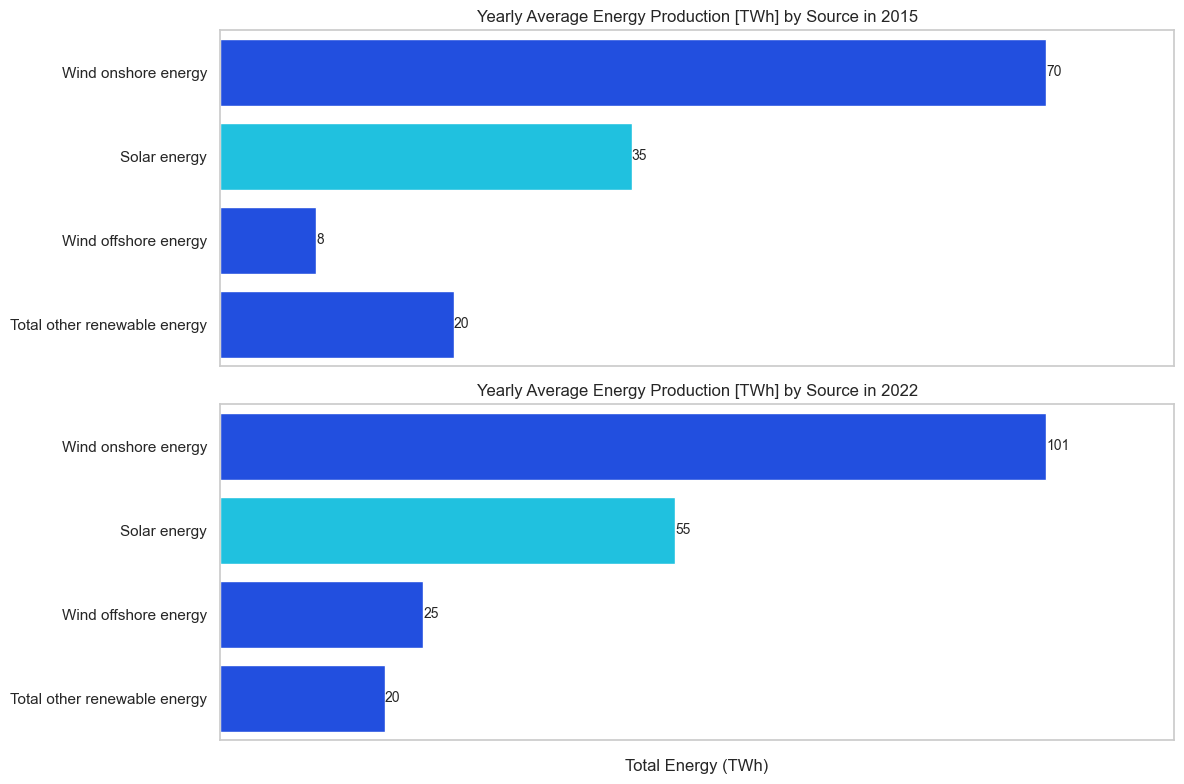

In [973]:
# ... (previous code)

# Create the plot
plt.figure(figsize=(12, 8))

# Set colors for energy sources
energy_colors = [sns.color_palette("bright")[0]] * 1 + [sns.color_palette("bright")[-1]] + [sns.color_palette("bright")[0]] * 3

# ... (rest of the code)

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax1.set_title('Yearly Average Energy Production [TWh] by Source in 2015')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)
ax1.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the value
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax2.set_title('Yearly Average Energy Production [TWh] by Source in 2022')
ax2.set_xlabel('Total Energy (TWh)')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)
ax2.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the value
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Turn off grid
ax1.grid(False)
ax2.grid(False)
# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


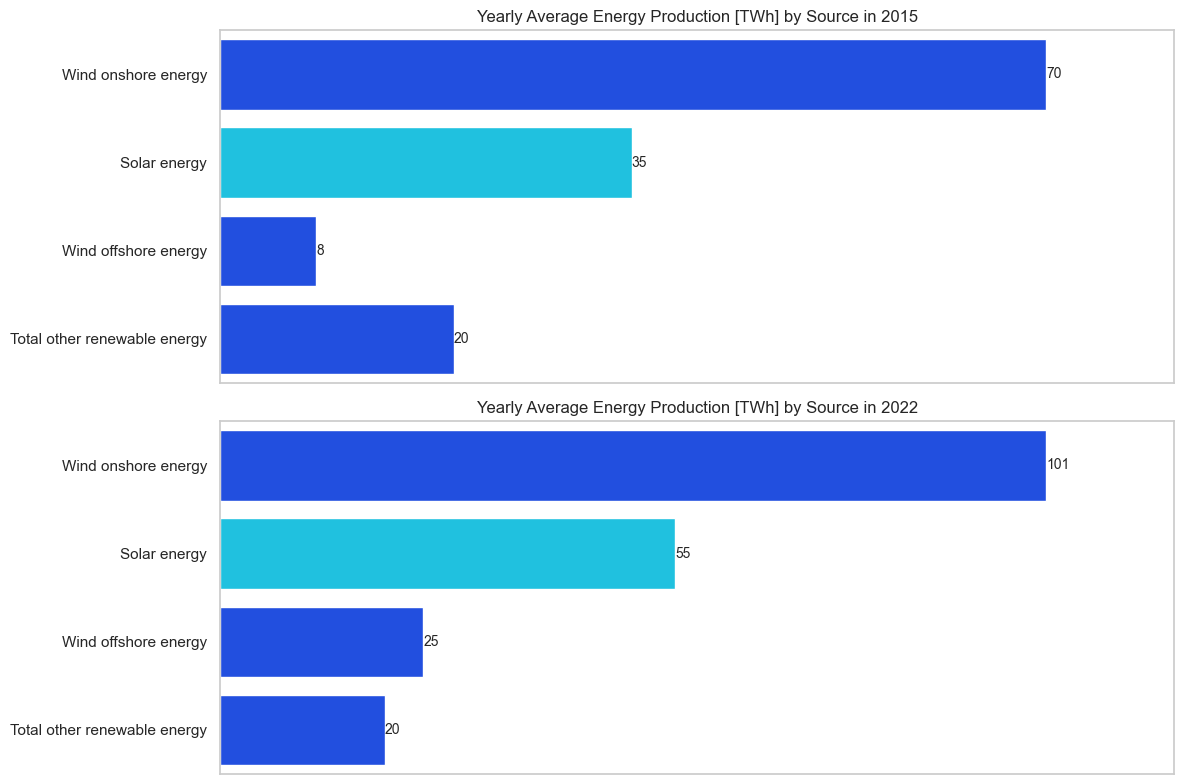

In [969]:

# Assuming 'Date' column is already in datetime format
data_dfN2['Date'] = pd.to_datetime(data_dfN1['Date'])

# Convert energy values in GWh columns to TWh
energy_columns = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
data_dfN2[energy_columns] = data_dfN2[energy_columns] / 1000.  # Convert GWh to TWh

# Extract year and create masks for the years 2015 and 2022
data_dfN2['Year'] = data_dfN2['Date'].dt.year
mask_2015 = data_dfN2['Year'] == 2015
mask_2022 = data_dfN2['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_dfN2[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()
data_2022_grouped = data_dfN2[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Single color for all energy except 'Solar energy'
#energy_colors = [sns.color_palette("bright")[0]] * 1 + [sns.color_palette("bright")[-1]]
energy_colors = [sns.color_palette("bright")[0]] * 1 + [sns.color_palette("bright")[-1]] + [sns.color_palette("bright")[0]] * 3


# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax1.set_title('Yearly Average Energy Production [TWh] by Source in 2015')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)
ax1.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax2.set_title('Yearly Average Energy Production [TWh] by Source in 2022')
#ax2.set_xlabel('Total Energy (TWh)')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)
ax2.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Turn off grid
ax1.grid(False)
ax2.grid(False)
# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


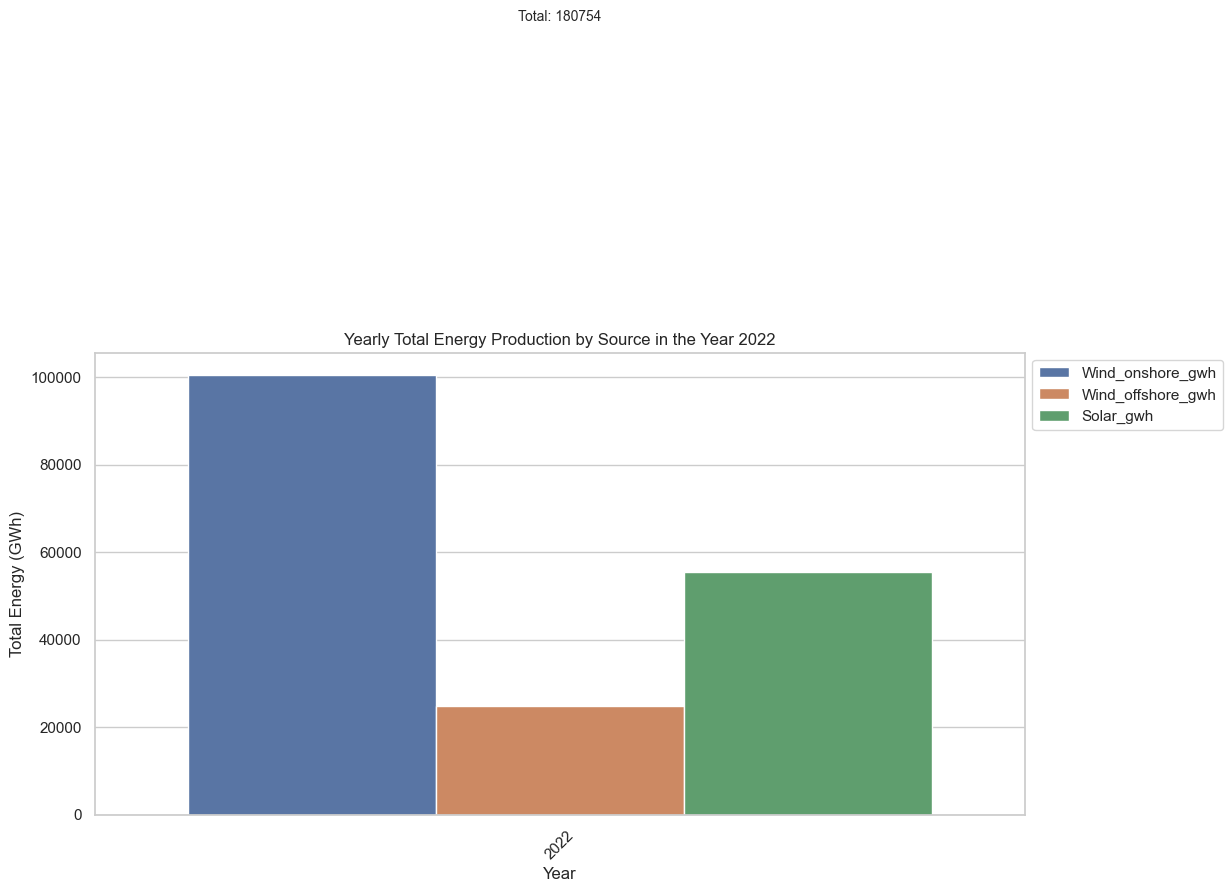

In [216]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create a mask for the year 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_gwh', 'Wind_offshore_gwh', 'Solar_gwh']

# Filter data for the year 2022 and selected columns
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=data_2022_grouped_melted, x='Date', y='Total Energy (GWh)', hue='Energy Source')

# Annotate each bar with the total energy production
for i, row in data_2022_grouped.iterrows():
    total = row[columns_to_plot].sum()
    plt.text(i, total + 10, f'Total: {total:.0f}', ha='center', va='bottom', fontsize=10)

# Customize labels and title
plt.xlabel('Year')
plt.ylabel('Total Energy (GWh)')
plt.title('Yearly Total Energy Production by Source in the Year 2022')

# Show the legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Show the plot
plt.show()


In [477]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear', 'Total_other_renewable_gwh_N'],
      dtype='object')

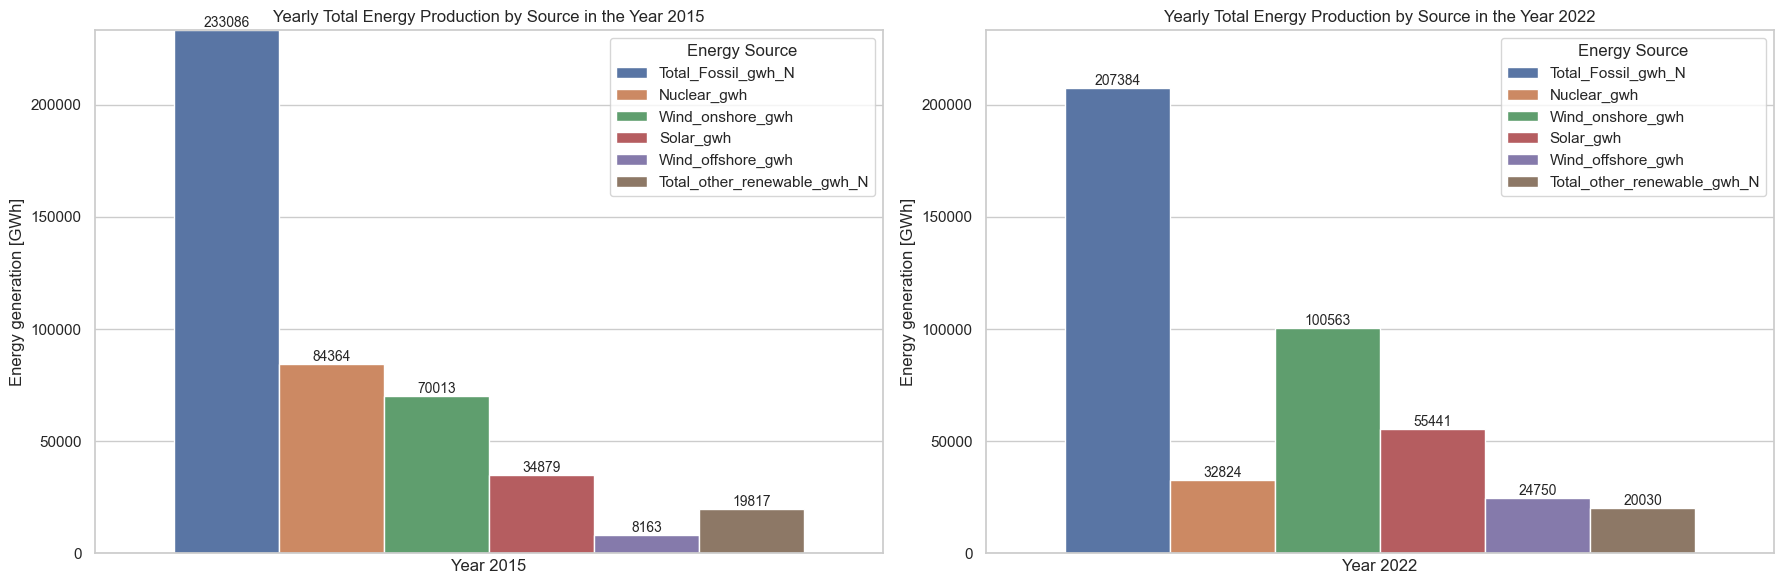

In [480]:


# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot

columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
#columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N', 'Total_Fossil_gwh_N', 'Nuclear_gwh']#, 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
                   #'Marine_gwh',  'Hydro_water_reservoir_gwh',
                   #'Geothermal_gwh']

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(18, 6))

# Plot for 2015
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, x='Date', y='Total Energy (GWh)', hue='Energy Source')
ax1.set_title('Yearly Total Energy Production by Source in the Year 2015')
ax1.set_ylabel('Energy generation [GWh]')
ax1.set_xlabel('Year 2015')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
y_max = max(data_2015_grouped_melted['Total Energy (GWh)'].max(), data_2022_grouped_melted['Total Energy (GWh)'].max())
ax1.set_xticks([])
ax1.set_ylim(0, y_max)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

# Plot for 2022
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, x='Date', y='Total Energy (GWh)', hue='Energy Source')
ax2.set_title('Yearly Total Energy Production by Source in the Year 2022')
ax2.set_ylabel('Energy generation [GWh]')
ax2.set_xlabel('Year 2022')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.set_ylim(0, y_max)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)
ax2.set_xticks([])
# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


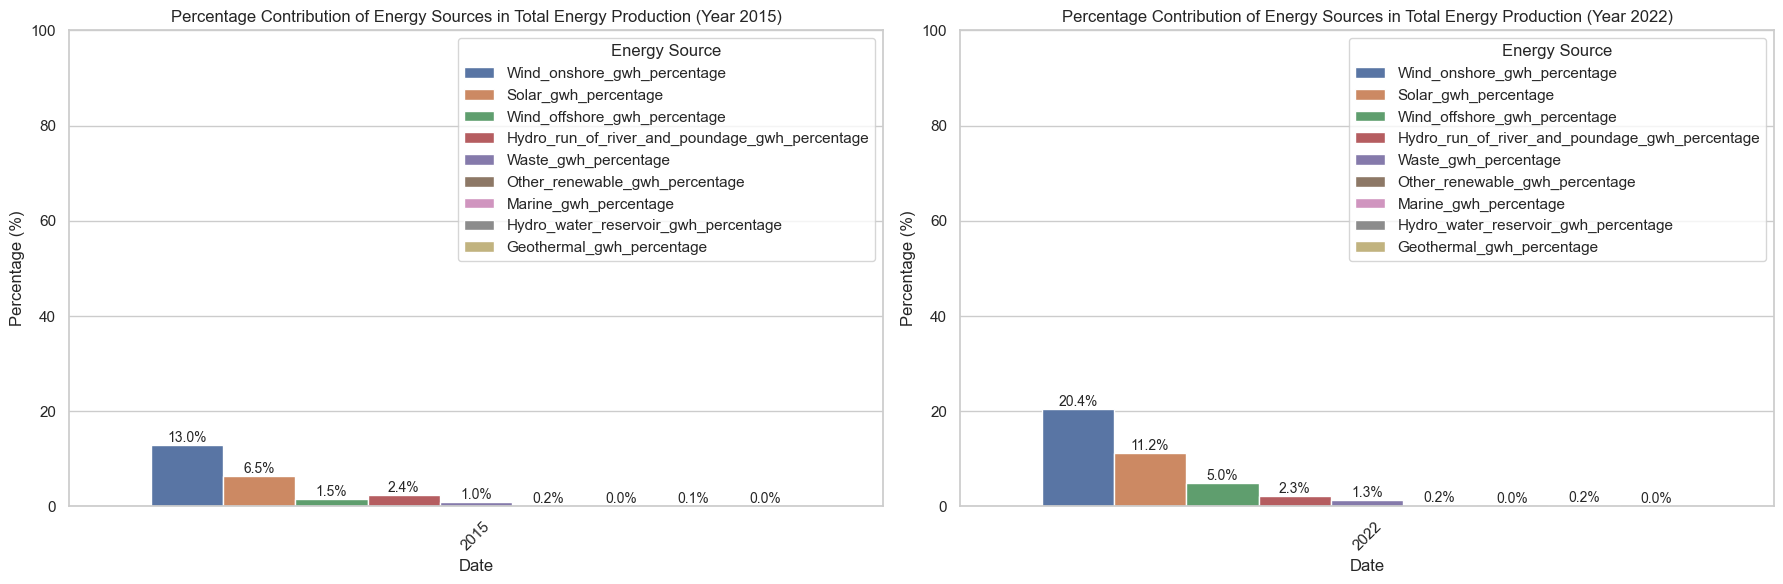

In [268]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
                   'Marine_gwh',  'Hydro_water_reservoir_gwh', 'Geothermal_gwh']

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot + ['Total_energy_generation_gwh']]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot + ['Total_energy_generation_gwh']]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot + ['Total_energy_generation_gwh']].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot + ['Total_energy_generation_gwh']].sum().reset_index()

# Calculate percentage contribution
for col in columns_to_plot:
    data_2015_grouped[col + '_percentage'] = (data_2015_grouped[col] / data_2015_grouped['Total_energy_generation_gwh']) * 100
    data_2022_grouped[col + '_percentage'] = (data_2022_grouped[col] / data_2022_grouped['Total_energy_generation_gwh']) * 100

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=[col + '_percentage' for col in columns_to_plot], var_name='Energy Source', value_name='Percentage')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=[col + '_percentage' for col in columns_to_plot], var_name='Energy Source', value_name='Percentage')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(18, 6))

# Plot for 2015
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, x='Date', y='Percentage', hue='Energy Source')
ax1.set_title('Percentage Contribution of Energy Sources in Total Energy Production (Year 2015)')
ax1.set_ylabel('Percentage (%)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.set_ylim(0, 100)

# Annotate bars with the percentage
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

# Plot for 2022
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, x='Date', y='Percentage', hue='Energy Source')
ax2.set_title('Percentage Contribution of Energy Sources in Total Energy Production (Year 2022)')
ax2.set_ylabel('Percentage (%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.set_ylim(0, 100)

# Annotate bars with the percentage
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


## Bar plots in Twh units

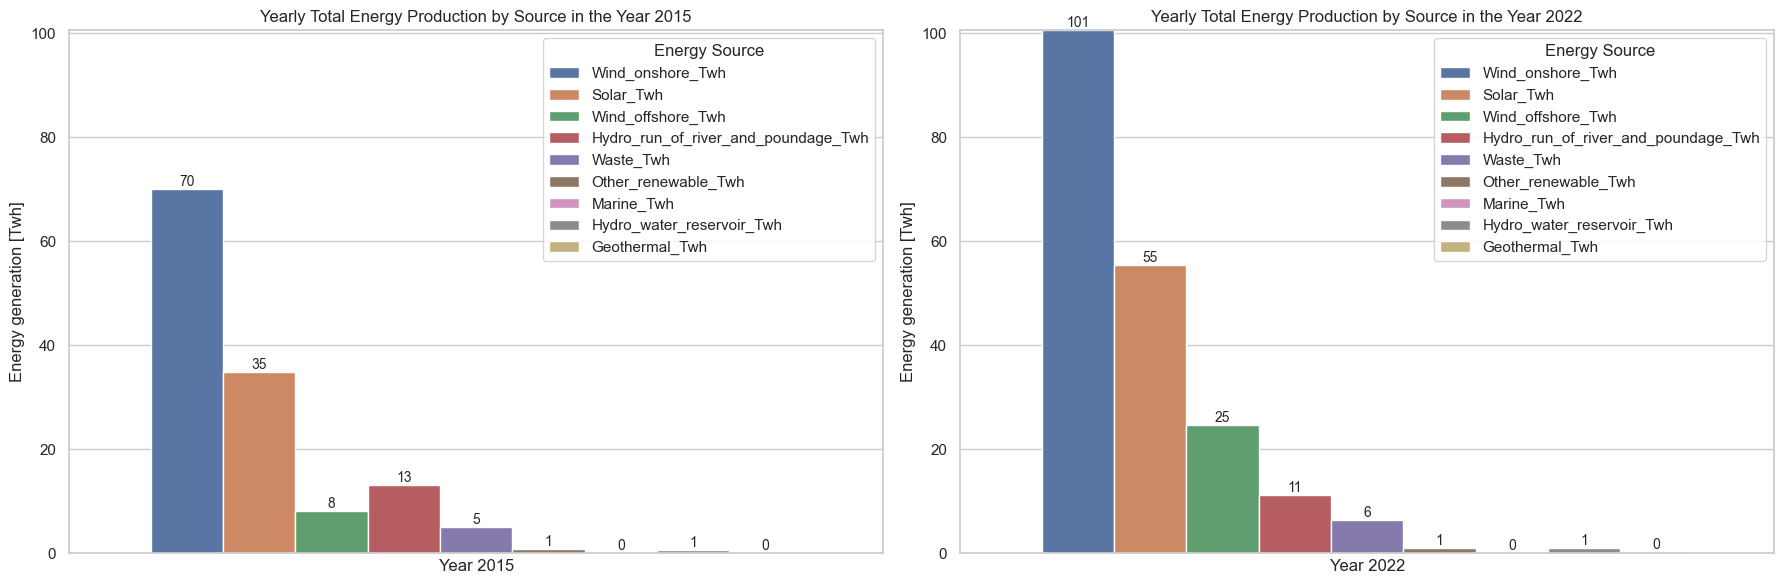

In [362]:


# Assuming 'Date' column is already in datetime format
data_df_twh['Date'] = pd.to_datetime(data_df_twh['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df_twh['Year'] = data_df_twh['Date'].dt.year
mask_2015 = data_df_twh['Year'] == 2015
mask_2022 = data_df_twh['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_Twh', 'Solar_Twh', 'Wind_offshore_Twh', 'Hydro_run_of_river_and_poundage_Twh', 'Waste_Twh', 'Other_renewable_Twh',
                   'Marine_Twh',  'Hydro_water_reservoir_Twh',
                   'Geothermal_Twh']

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df_twh[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df_twh[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (Twh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (Twh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(18, 6))

# Plot for 2015
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, x='Date', y='Total Energy (Twh)', hue='Energy Source')
ax1.set_title('Yearly Total Energy Production by Source in the Year 2015')
ax1.set_ylabel('Energy generation [Twh]')
ax1.set_xlabel('Year 2015')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
y_max = max(data_2015_grouped_melted['Total Energy (Twh)'].max(), data_2022_grouped_melted['Total Energy (Twh)'].max())
ax1.set_xticks([])
ax1.set_ylim(0, y_max)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

# Plot for 2022
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, x='Date', y='Total Energy (Twh)', hue='Energy Source')
ax2.set_title('Yearly Total Energy Production by Source in the Year 2022')
ax2.set_ylabel('Energy generation [Twh]')
ax2.set_xlabel('Year 2022')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.set_ylim(0, y_max)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)
ax2.set_xticks([])
# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


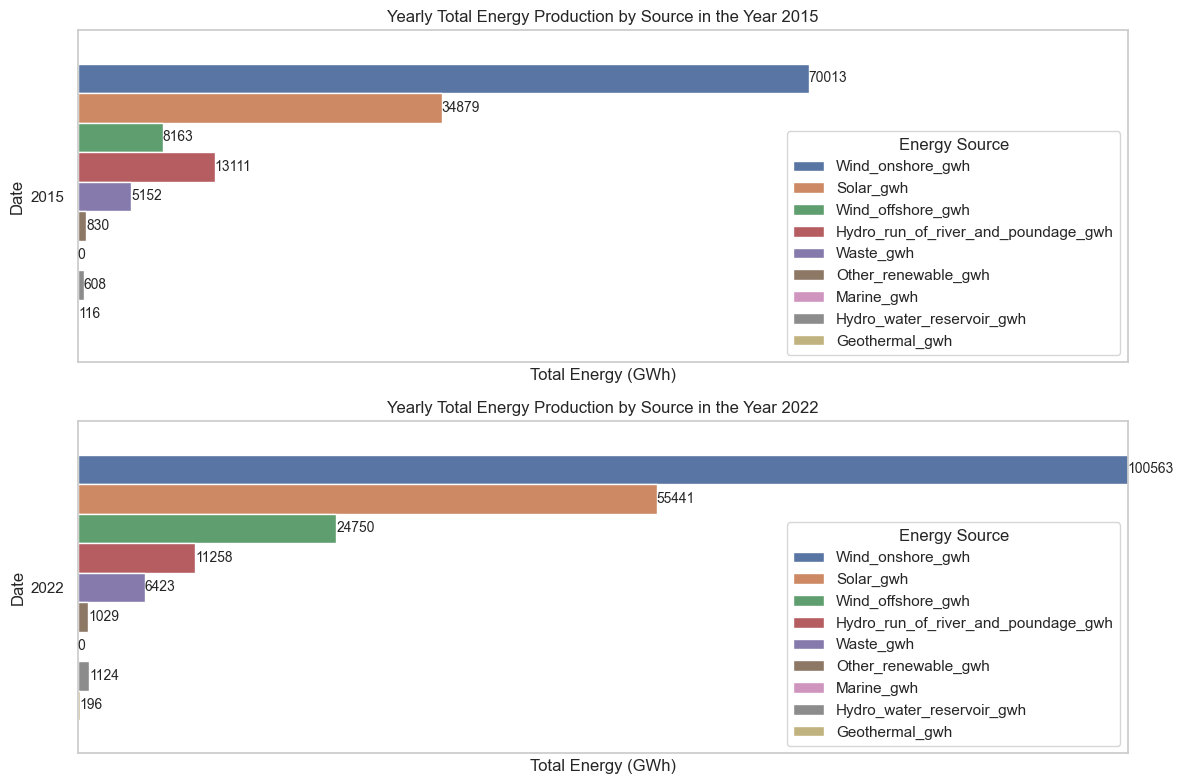

In [365]:
# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
                   'Marine_gwh',  'Hydro_water_reservoir_gwh', 'Geothermal_gwh']

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Date', x='Total Energy (GWh)', hue='Energy Source', orient='h')
ax1.set_title('Yearly Total Energy Production by Source in the Year 2015')
#ax1.set_xlabel('Energy generation [GWh]')
#ax1.set_ylabel('Year 2015')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
y_max = max(data_2015_grouped_melted['Total Energy (GWh)'].max(), data_2022_grouped_melted['Total Energy (GWh)'].max())
ax1.set_xticks([])
ax1.set_xlim(0, y_max)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Date', x='Total Energy (GWh)', hue='Energy Source', orient='h')
ax2.set_title('Yearly Total Energy Production by Source in the Year 2022')
#ax2.set_xlabel('Energy generation [GWh]')
#ax2.set_ylabel('Year 2022')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)
ax2.set_xlim(0, y_max)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)
ax2.set_xticks([])

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


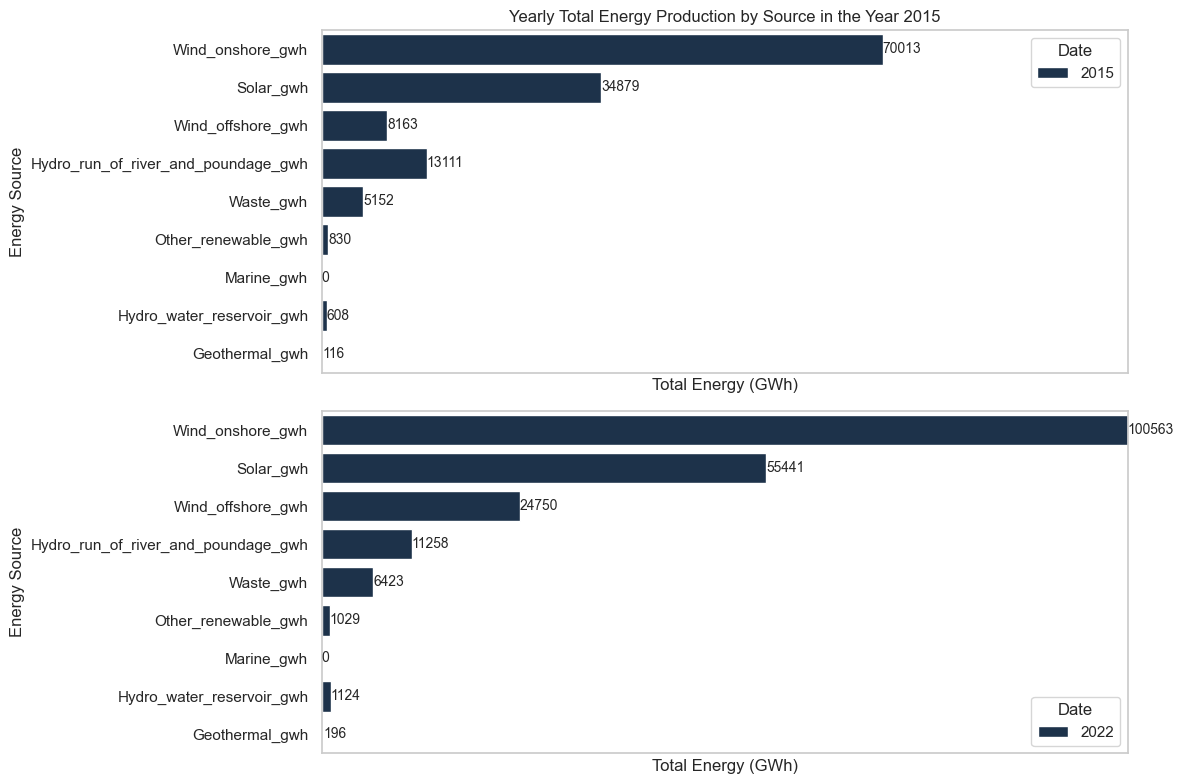

In [386]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
                   'Marine_gwh',  'Hydro_water_reservoir_gwh', 'Geothermal_gwh']

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=['#163251'])
ax1.set_title('Yearly Total Energy Production by Source in the Year 2015')
#ax1.set_xlabel('Energy generation [GWh]')
#ax1.set_ylabel('Energy Source')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
y_max = max(data_2015_grouped_melted['Total Energy (GWh)'].max(), data_2022_grouped_melted['Total Energy (GWh)'].max())
ax1.set_xticks([])
ax1.set_xlim(0, y_max)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=['#163251'])
#ax2.set_title('Yearly Total Energy Production by Source in the Year 2022')
#ax2.set_xlabel('Energy generation [GWh]')
#ax2.set_ylabel('Energy Source')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)
ax2.set_xlim(0, y_max)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)
ax2.set_xticks([])

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


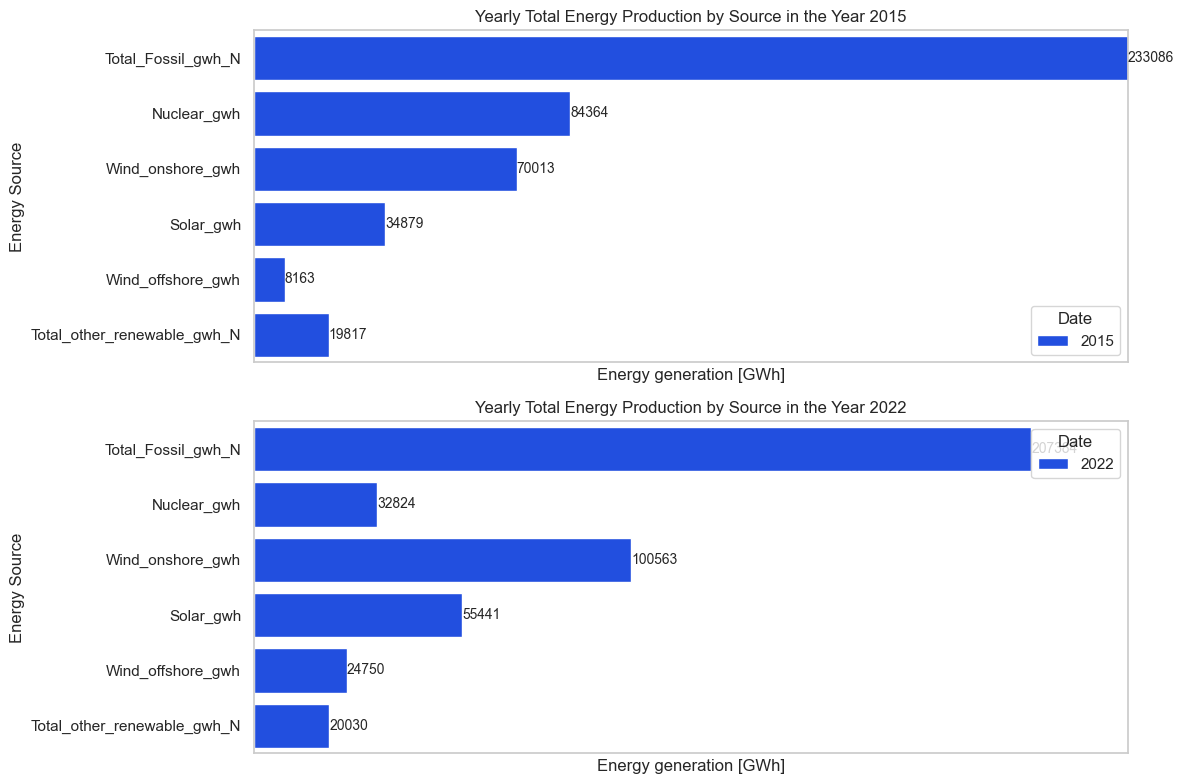

In [482]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
#columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
 #                  'Marine_gwh',  'Hydro_water_reservoir_gwh', 'Geothermal_gwh']

columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
#

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Bright color palette
bright_palette = sns.color_palette("bright")

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax1.set_title('Yearly Total Energy Production by Source in the Year 2015')
ax1.set_xlabel('Energy generation [GWh]')
ax1.set_ylabel('Energy Source')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
y_max = max(data_2015_grouped_melted['Total Energy (GWh)'].max(), data_2022_grouped_melted['Total Energy (GWh)'].max())
ax1.set_xticks([])
ax1.set_xlim(0, y_max)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax2.set_title('Yearly Total Energy Production by Source in the Year 2022')
ax2.set_xlabel('Energy generation [GWh]')
ax2.set_ylabel('Energy Source')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)
ax2.set_xlim(0, y_max)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)
ax2.set_xticks([])

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


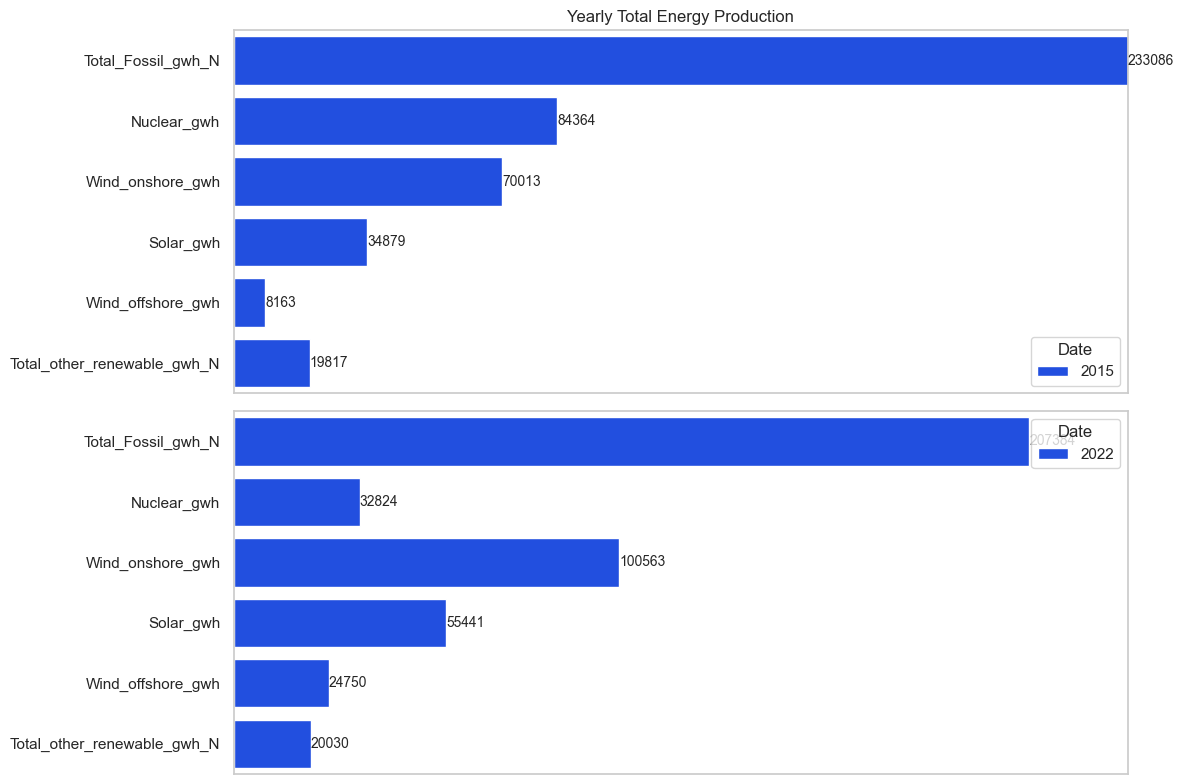

In [483]:

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
#columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
 #                  'Marine_gwh',  'Hydro_water_reservoir_gwh', 'Geothermal_gwh']
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
#
# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Bright color palette
bright_palette = sns.color_palette("bright")

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax1.set_title('Yearly Total Energy Production')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
y_max = max(data_2015_grouped_melted['Total Energy (GWh)'].max(), data_2022_grouped_melted['Total Energy (GWh)'].max())
ax1.set_xticks([])
ax1.set_xlim(0, y_max)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
#ax2.set_title('Yearly Total Energy Production by Source in the Year 2022')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)
ax2.set_xlim(0, y_max)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)
ax2.set_xticks([])

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


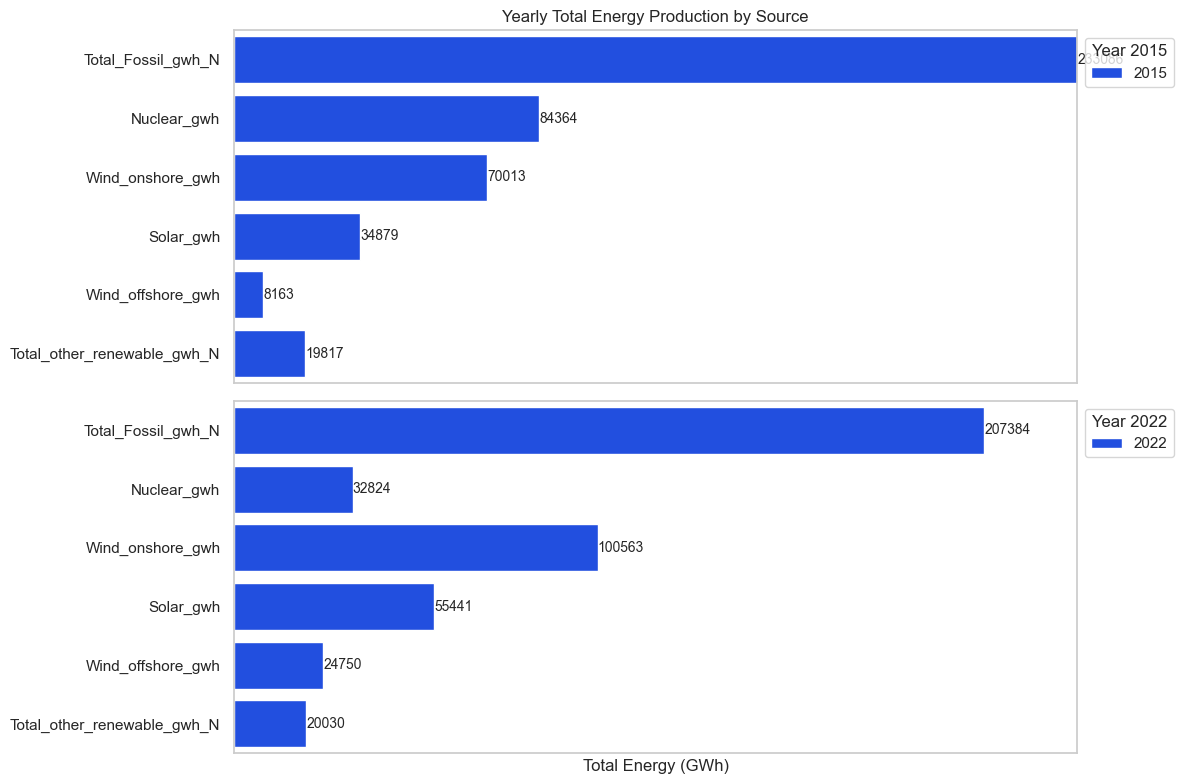

In [484]:
# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
#columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
 #                  'Marine_gwh',  'Hydro_water_reservoir_gwh', 'Geothermal_gwh']
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
#
# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Bright color palette
bright_palette = sns.color_palette("bright")

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax1.set_title('Yearly Total Energy Production by Source')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
y_max = max(data_2015_grouped_melted['Total Energy (GWh)'].max(), data_2022_grouped_melted['Total Energy (GWh)'].max())
ax1.set_xticks([])
ax1.set_xlim(0, y_max)
ax1.legend(title='Year 2015', loc='upper left', bbox_to_anchor=(1, 1))

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax2.set_xlabel('Total Energy (GWh)')
ax2.set_ylabel('')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)
ax2.set_xlim(0, y_max)
ax2.legend(title='Year 2022', loc='upper left', bbox_to_anchor=(1, 1))

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)
ax2.set_xticks([])

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


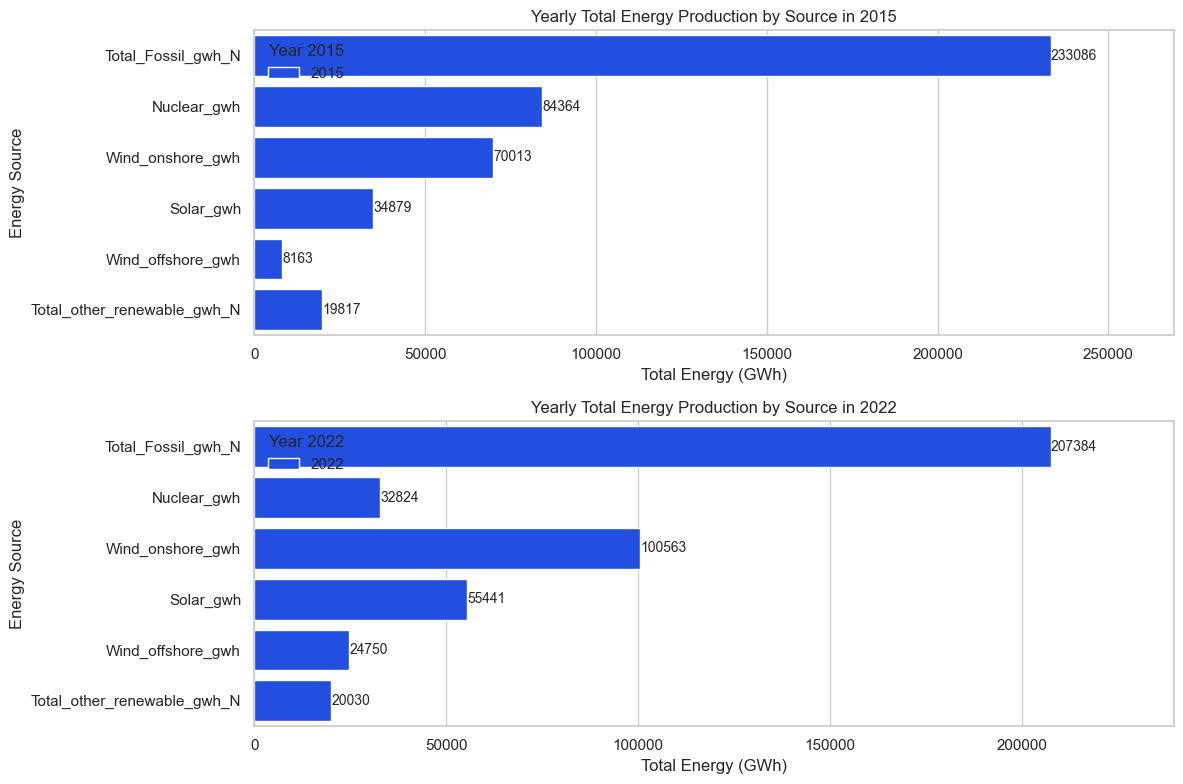

In [485]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
#columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
 #                  'Marine_gwh',  'Hydro_water_reservoir_gwh', 'Geothermal_gwh']
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
#

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Bright color palette
bright_palette = sns.color_palette("bright")

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax1.set_title('Yearly Total Energy Production by Source in 2015')
ax1.set_xlabel('Total Energy (GWh)')
ax1.set_ylabel('Energy Source')
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend(title='Year 2015', loc='upper left', bbox_to_anchor=(0, 1), frameon=False)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax2.set_title('Yearly Total Energy Production by Source in 2022')
ax2.set_xlabel('Total Energy (GWh)')
ax2.set_ylabel('Energy Source')
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend(title='Year 2022', loc='upper left', bbox_to_anchor=(0, 1), frameon=False)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


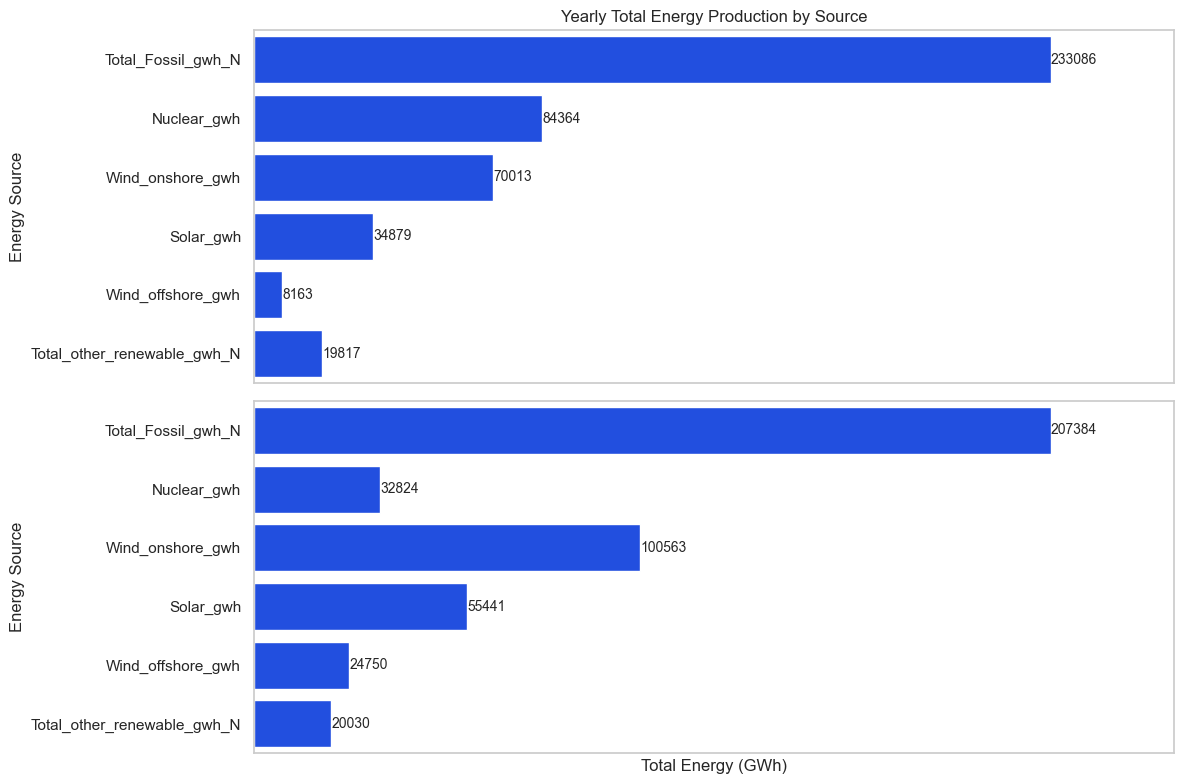

In [487]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022
#['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N'] to ['Total fossil energy', 'Nuclear energy', 'Wind onshore energy', 'Solar energy', 'Wind offshore energy', 'Total other renewable energy']
# Columns to plot
#columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
#                   'Marine_gwh',  'Hydro_water_reservoir_gwh', 'Geothermal_gwh']
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
#
# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Bright color palette
bright_palette = sns.color_palette("bright")

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax1.set_title('Yearly Total Energy Production by Source')
ax1.set_xlabel('')
ax1.set_ylabel('Energy Source')
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.set_xticks([])
ax1.legend().set_visible(False)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax2.set_xlabel('Total Energy (GWh)')
ax2.set_ylabel('Energy Source')
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.set_xticks([])
ax2.legend().set_visible(False)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


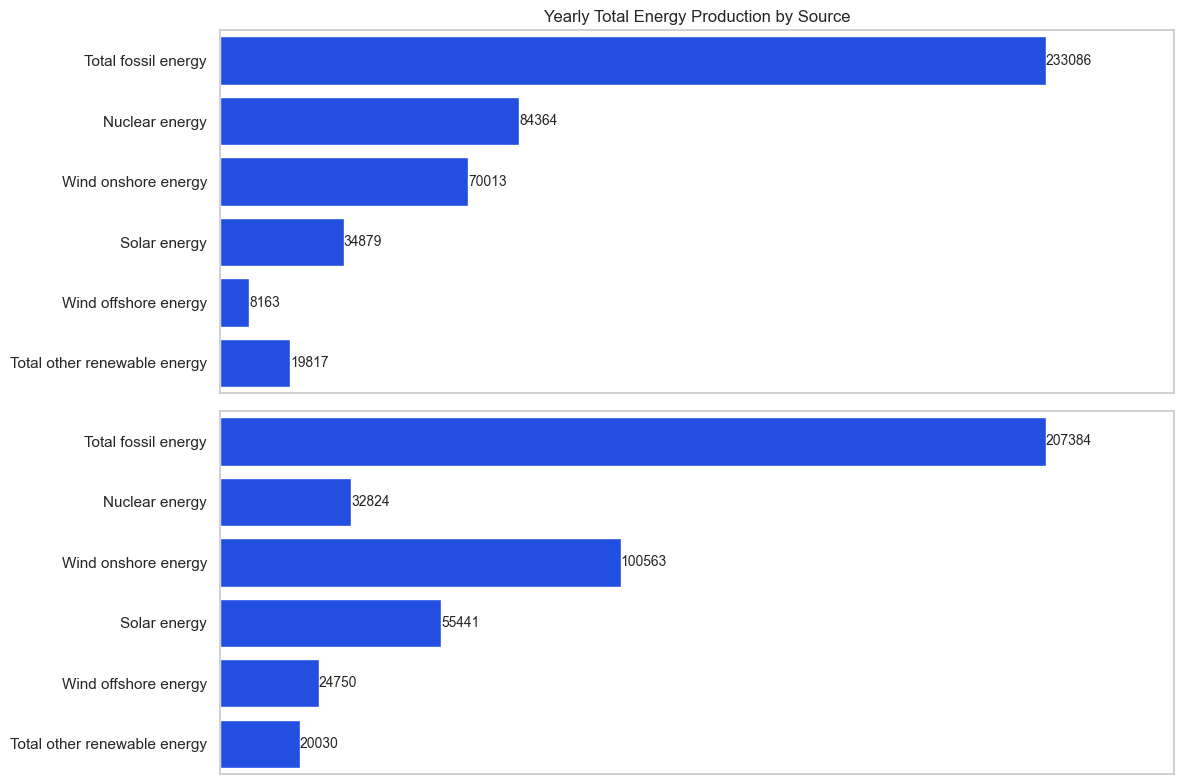

In [489]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Bright color palette
bright_palette = sns.color_palette("bright")

# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax1.set_title('Yearly Total Energy Production by Source')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.set_xticks([])
ax1.legend().set_visible(False)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.set_xticks([])
ax2.legend().set_visible(False)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


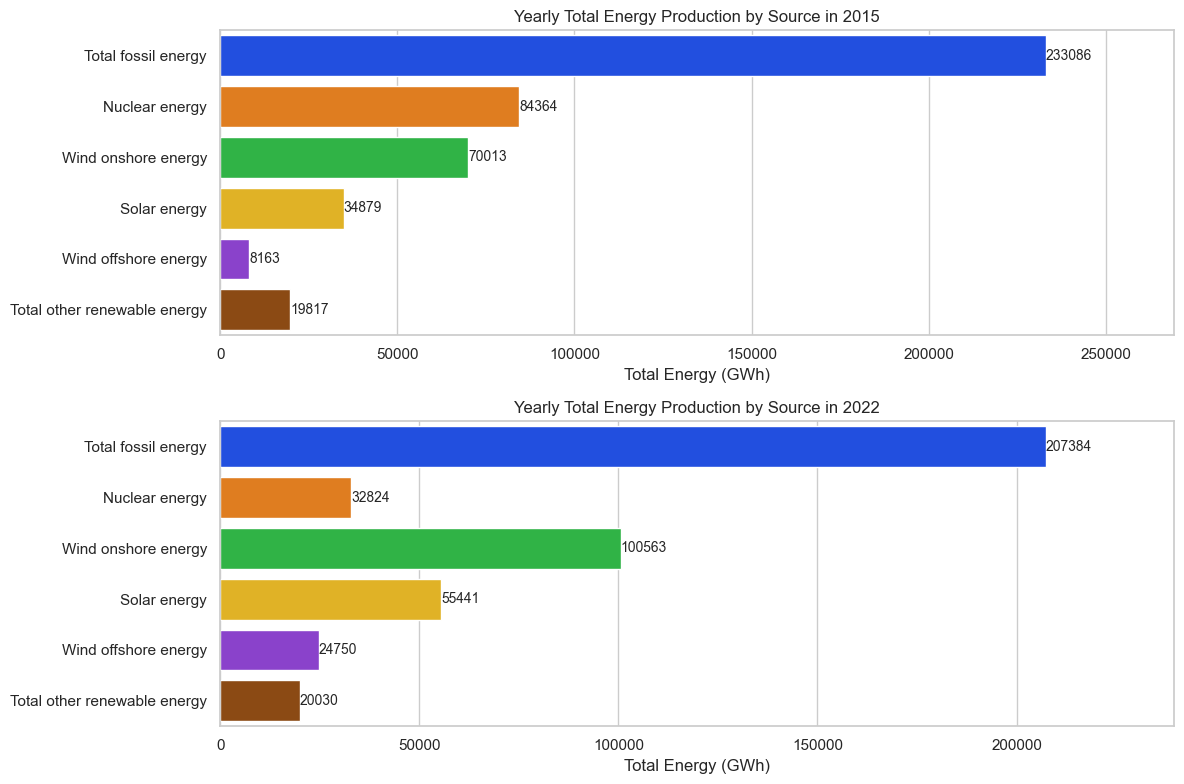

In [495]:
# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Calculate yearly sum of each energy source for 2015 and 2022
yearly_sum_2015 = data_df[mask_2015].resample('Y', on='Date')[columns_to_plot].sum()
yearly_sum_2022 = data_df[mask_2022].resample('Y', on='Date')[columns_to_plot].sum()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = yearly_sum_2015.melt(value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = yearly_sum_2022.melt(value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Bright color palette for non-solar columns
bright_palette = sns.color_palette("bright")

# Create a custom color palette with a contrasting color for 'Solar_gwh' column
custom_palette = [bright_palette[i] if col != 'Solar_gwh' else '#FFC107' for i, col in enumerate(columns_to_plot)]

# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (GWh)', palette=custom_palette)
ax1.set_title('Yearly Total Energy Production by Source in 2015')
ax1.set_xlabel('Total Energy (GWh)')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (GWh)', palette=custom_palette)
ax2.set_title('Yearly Total Energy Production by Source in 2022')
ax2.set_xlabel('Total Energy (GWh)')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


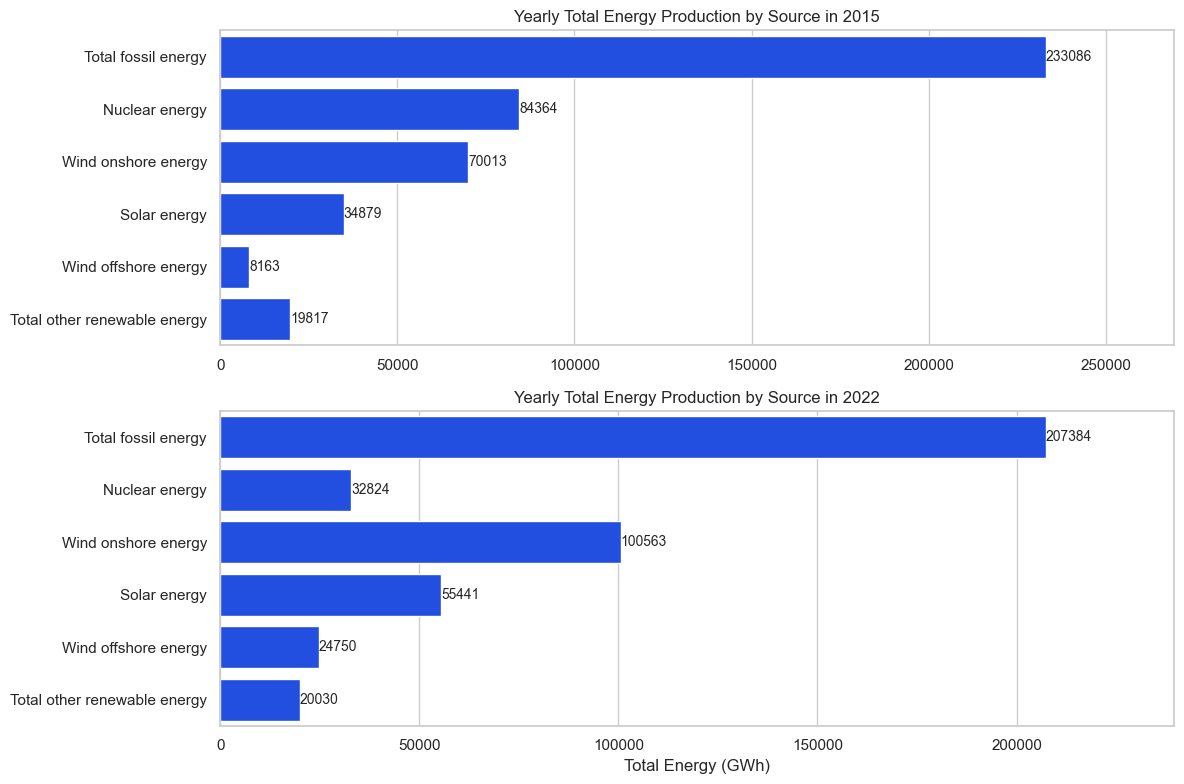

In [501]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_df[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()
data_2022_grouped = data_df[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Single color for all data points
color = sns.color_palette("bright")[0]

# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (GWh)', color=color)
ax1.set_title('Yearly Total Energy Production by Source in 2015')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (GWh)', color=color)
ax2.set_title('Yearly Total Energy Production by Source in 2022')
ax2.set_xlabel('Total Energy (GWh)')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


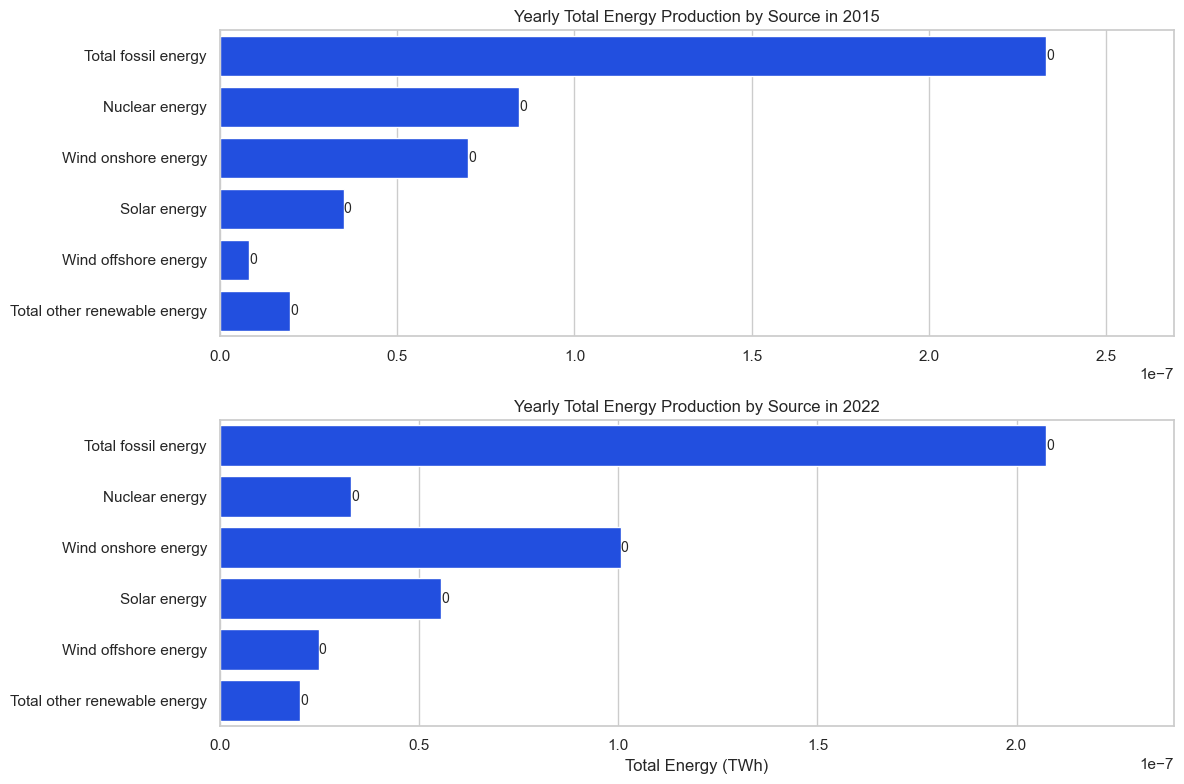

In [566]:


# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Convert energy values in GWh columns to TWh
energy_columns = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']#['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh', 'Marine_gwh', 'Hydro_water_reservoir_gwh', 'Geothermal_gwh']
data_df[energy_columns] = data_df[energy_columns] / 1000  # Convert GWh to TWh

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_df[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()
data_2022_grouped = data_df[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Single color for all data points
color = sns.color_palette("bright")[0]

# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (TWh)', color=color)
ax1.set_title('Yearly Total Energy Production by Source in 2015')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (TWh)', color=color)
ax2.set_title('Yearly Total Energy Production by Source in 2022')
ax2.set_xlabel('Total Energy (TWh)')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


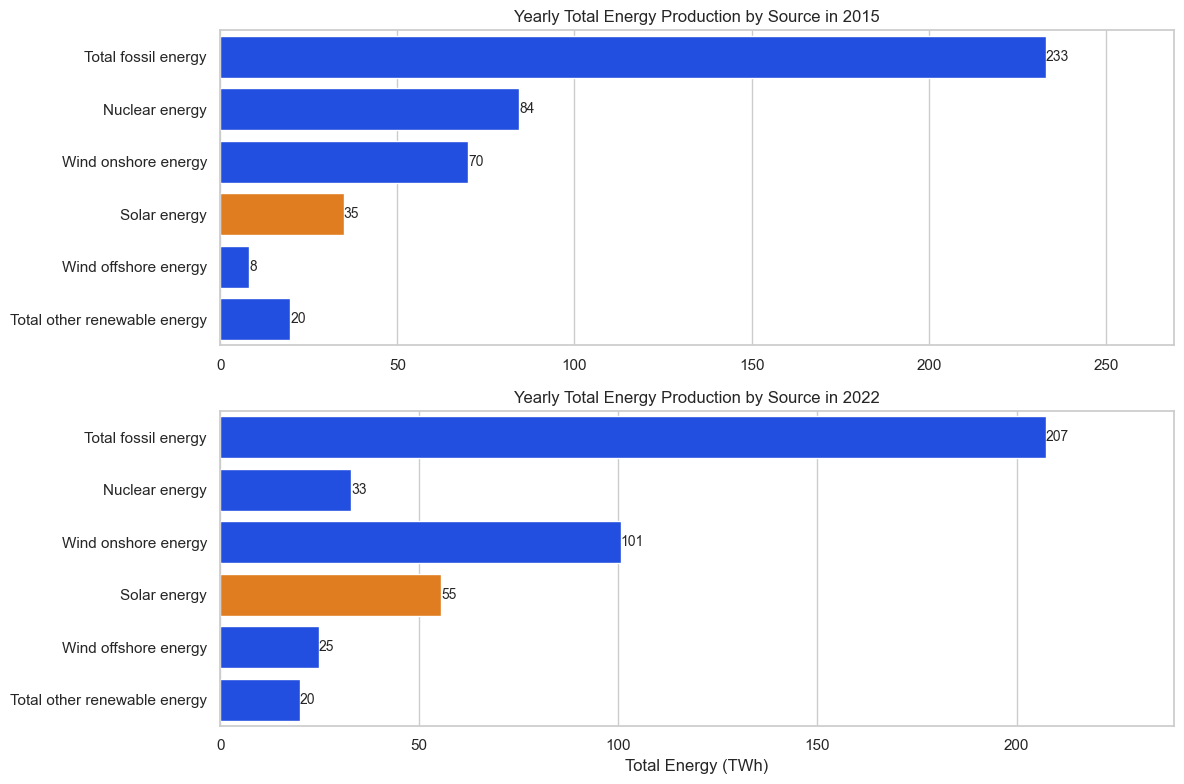

In [632]:

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Convert energy values in GWh columns to TWh
energy_columns = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
data_df[energy_columns] = data_df[energy_columns] / 1000  # Convert GWh to TWh

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_df[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()
data_2022_grouped = data_df[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Single color for all energy except 'Solar energy'
energy_colors = [sns.color_palette("bright")[0]] * 3 + [sns.color_palette("bright")[1]]

# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax1.set_title('Yearly Total Energy Production by Source in 2015')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax2.set_title('Yearly Total Energy Production by Source in 2022')
ax2.set_xlabel('Total Energy (TWh)')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


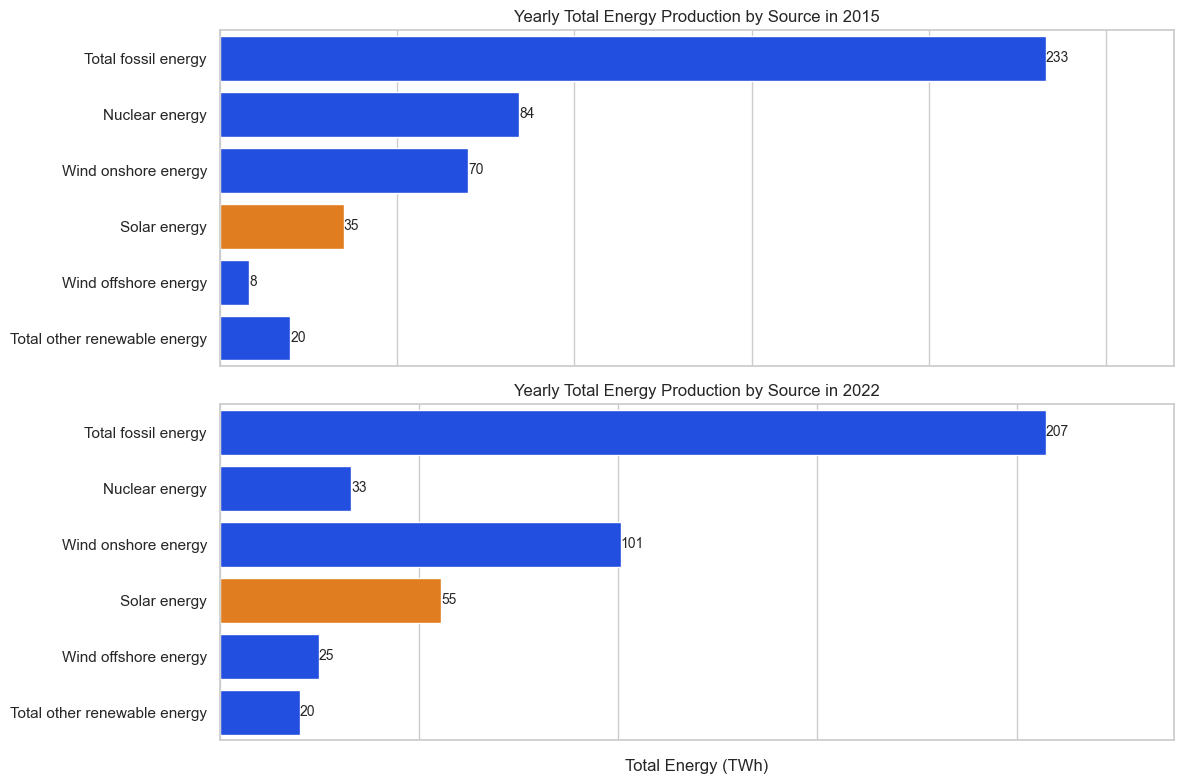

In [707]:

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Convert energy values in GWh columns to TWh
energy_columns = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
data_df[energy_columns] = data_df[energy_columns] / 1000  # Convert GWh to TWh

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_df[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()
data_2022_grouped = data_df[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Single color for all energy except 'Solar energy'
energy_colors = [sns.color_palette("bright")[0]] * 3 + [sns.color_palette("bright")[1]]

# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax1.set_title('Yearly Total Energy Production by Source in 2015')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)
ax1.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax2.set_title('Yearly Total Energy Production by Source in 2022')
ax2.set_xlabel('Total Energy (TWh)')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)
ax2.set_xticklabels([])  # Remove x-axis labels

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


TypeError: cannot perform __rtruediv__ with this index type: DatetimeArray

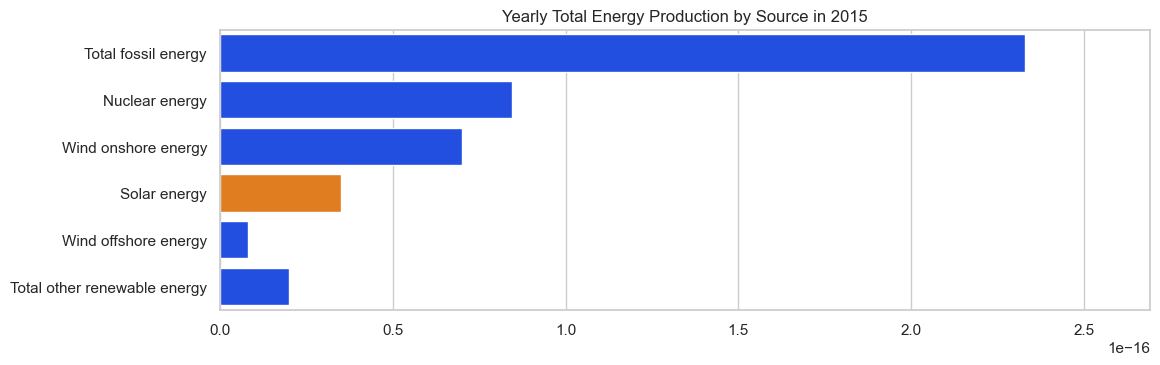

In [640]:


# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Convert energy values in GWh columns to TWh
energy_columns = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']
data_df[energy_columns] = data_df[energy_columns] / 1000  # Convert GWh to TWh

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Total_Fossil_gwh_N', 'Nuclear_gwh', 'Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Total_other_renewable_gwh_N']

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_df[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()
data_2022_grouped = data_df[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[columns_to_plot].sum().reset_index()

# Calculate yearly average of 'Total Energy (TWh)' column
#yearly_avg_2015 = data_2015_grouped['Total_energy_generation_gwh'].sum()
#yearly_avg_2022 = data_2022_grouped['Total_energy_generation_gwh'].sum()

# Calculate the total energy generated for each year
#yearly_avg_2015 =  data_df[mask_2015]['Total_energy_generation_gwh'].sum()
#yearly_avg_2022 = data_df[mask_2022]['Total_energy_generation_gwh'].sum()

yearly_avg_2015 = data_df[mask_2015].groupby(pd.Grouper(key='Date', freq='Y'))[['Total_energy_generation_gwh']].sum().reset_index()
yearly_avg_2022 = data_df[mask_2022].groupby(pd.Grouper(key='Date', freq='Y'))[['Total_energy_generation_gwh']].sum().reset_index()

#yearly_avg_2015 = yearly_avg_2015/1000.
#yearly_avg_2022 = yearly_avg_2022/1000.


# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')
data_2022_grouped_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (TWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Single color for all energy except 'Solar energy'
energy_colors = [sns.color_palette("bright")[0]] * 3 + [sns.color_palette("bright")[1]]

# Energy Source labels mapping
energy_source_labels = {
    'Total_Fossil_gwh_N': 'Total fossil energy',
    'Nuclear_gwh': 'Nuclear energy',
    'Wind_onshore_gwh': 'Wind onshore energy',
    'Solar_gwh': 'Solar energy',
    'Wind_offshore_gwh': 'Wind offshore energy',
    'Total_other_renewable_gwh_N': 'Total other renewable energy'
}

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax1.set_title('Yearly Total Energy Production by Source in 2015')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_yticklabels([energy_source_labels[label.get_text()] for label in ax1.get_yticklabels()])  # Update y-axis labels
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.legend().set_visible(False)

# Annotate bars with the percentage
for p in ax1.patches:
    percentage = (p.get_width() / yearly_avg_2015) * 100
    ax1.annotate(f'{percentage:.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Total Energy (TWh)', palette=energy_colors)
ax2.set_title('Yearly Total Energy Production by Source in 2022')
ax2.set_xlabel('Total Energy (TWh)')
ax2.set_ylabel('')
ax2.set_yticklabels([energy_source_labels[label.get_text()] for label in ax2.get_yticklabels()])  # Update y-axis labels
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.legend().set_visible(False)

# Annotate bars with the percentage
for p in ax2.patches:
    percentage = (p.get_width() / yearly_avg_2022) * 100
    ax2.annotate(f'{percentage:.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh',
                   'Waste_gwh', 'Other_renewable_gwh', 'Marine_gwh', 'Hydro_water_reservoir_gwh', 'Geothermal_gwh']

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Melt the data to create a suitable format for plotting
data_2015_melted = data_2015_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')
data_2022_melted = data_2022_grouped.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Total Energy (GWh)')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Bright color palette
bright_palette = sns.color_palette("bright")

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax1.set_title('Yearly Total Energy Production by Source')
ax1.set_xlabel('')
ax1.set_ylabel('Energy Source')
ax1.set_xlim(0, ax1.get_xlim()[1] * 1.1)
ax1.set_xticks([])
ax1.legend().set_visible(False)

# Annotate bars with the last number
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_melted, y='Energy Source', x='Total Energy (GWh)', hue='Date', orient='h', palette=bright_palette)
ax2.set_xlabel('')
ax2.set_ylabel('Energy Source')
ax2.set_xlim(0, ax2.get_xlim()[1] * 1.1)
ax2.set_xticks([])
ax2.legend().set_visible(False)

# Annotate bars with the last number
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.0f}', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


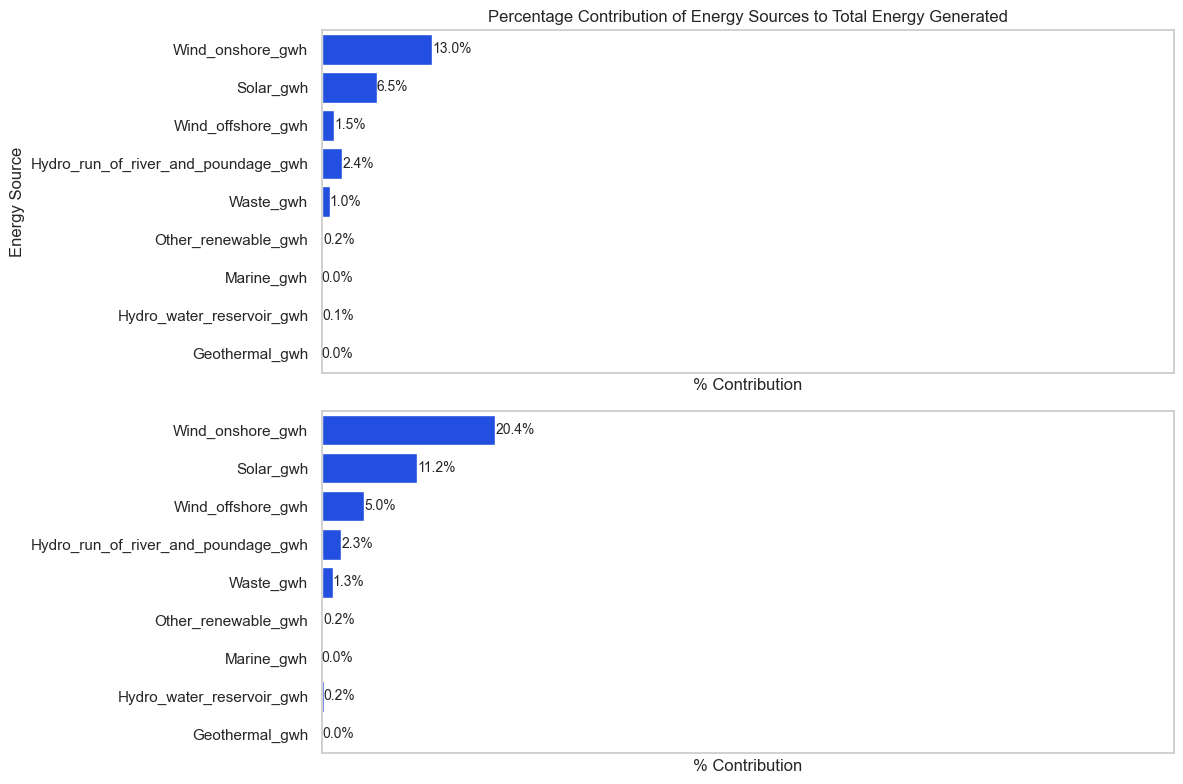

In [399]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame (replace this with your actual data)
# data_df = ...

# Assuming 'Date' column is already in datetime format
data_df['Date'] = pd.to_datetime(data_df['Date'])

# Extract year and create masks for the years 2015 and 2022
data_df['Year'] = data_df['Date'].dt.year
mask_2015 = data_df['Year'] == 2015
mask_2022 = data_df['Year'] == 2022

# Columns to plot
columns_to_plot = ['Wind_onshore_gwh', 'Solar_gwh', 'Wind_offshore_gwh', 'Hydro_run_of_river_and_poundage_gwh', 'Waste_gwh', 'Other_renewable_gwh',
                   'Marine_gwh',  'Hydro_water_reservoir_gwh', 'Geothermal_gwh']

# Filter data for the years 2015 and 2022 and selected columns
data_2015 = data_df[mask_2015][['Date'] + columns_to_plot]
data_2022 = data_df[mask_2022][['Date'] + columns_to_plot]

# Group data by year and calculate the sum for each energy source
data_2015_grouped = data_2015.groupby(data_2015['Date'].dt.year)[columns_to_plot].sum().reset_index()
data_2022_grouped = data_2022.groupby(data_2022['Date'].dt.year)[columns_to_plot].sum().reset_index()

# Calculate the total energy generated for each year
total_energy_2015 = data_df[mask_2015]['Total_energy_generation_gwh'].sum()
total_energy_2022 = data_df[mask_2022]['Total_energy_generation_gwh'].sum()

# Calculate the percentage contribution of each energy source
data_2015_grouped_percentage = data_2015_grouped.copy()
data_2022_grouped_percentage = data_2022_grouped.copy()

for column in columns_to_plot:
    data_2015_grouped_percentage[column] = (data_2015_grouped_percentage[column] / total_energy_2015) * 100
    data_2022_grouped_percentage[column] = (data_2022_grouped_percentage[column] / total_energy_2022) * 100

# Melt the data to create a suitable format for plotting
data_2015_grouped_melted = data_2015_grouped_percentage.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Percentage')
data_2022_grouped_melted = data_2022_grouped_percentage.melt(id_vars='Date', value_vars=columns_to_plot, var_name='Energy Source', value_name='Percentage')

# Set plot style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 8))

# Bright color palette
bright_palette = sns.color_palette("bright")

# Plot for 2015
plt.subplot(2, 1, 1)
ax1 = sns.barplot(data=data_2015_grouped_melted, y='Energy Source', x='Percentage', hue='Date', orient='h', palette=bright_palette)
ax1.set_title('Percentage Contribution of Energy Sources to Total Energy Generated')
ax1.set_xlabel('% Contribution')
ax1.set_ylabel('Energy Source')
ax1.set_xlim(0, 100)
ax1.set_xticks([])
ax1.legend().set_visible(False)

# Annotate bars with the percentage
for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Plot for 2022
plt.subplot(2, 1, 2)
ax2 = sns.barplot(data=data_2022_grouped_melted, y='Energy Source', x='Percentage', hue='Date', orient='h', palette=bright_palette)
ax2.set_xlabel('% Contribution')
ax2.set_ylabel('')
ax2.set_xlim(0, 100)
ax2.set_xticks([])
ax2.legend().set_visible(False)

# Annotate bars with the percentage
for p in ax2.patches:
    ax2.annotate(f'{p.get_width():.1f}%', (p.get_width(), p.get_y() + p.get_height() / 2.), ha='left', va='center', fontsize=10)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()


In [ ]:
Total_energy_generation_gwh

yearly_avg = data_df.groupby([data_df['Date'].dt.year, pd.Grouper(key='Date', freq='Y')])['Total_energy_generation_gwh'].sum()
